スペクトログラム＆フォルマント周波数の波形出力

In [4]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import lfilter
import soundfile as sf
import os

# ==========================================
# 1. 設定：比較したい2つの音声ファイル名
# ==========================================
files = {
    'harusu': 'nanishi_150_harusu_150_20260608_113724.wav',
    # 💡もう1つの「はるの」のファイル名（113650など）をここに正確に書いてください
    'haruno': 'nanishi_haruno_20260517_180128.wav' 
}

# フォルマント抽出用の内部関数（廣瀬さんのコードを移植）
def estimate_formants(y, sr):
    y_filt = lfilter([1, -0.63], [1], y)
    frame_length = int(0.025 * sr)
    hop_length = int(0.010 * sr)
    frames = librosa.util.frame(y_filt, frame_length=frame_length, hop_length=hop_length)
    f1_list, f2_list = [], []
    for frame in frames.T:
        windowed = frame * np.hamming(len(frame))
        a = librosa.lpc(windowed, order=18)
        roots = np.roots(a)
        roots = [r for r in roots if np.imag(r) >= 0]
        ang = np.arctan2(np.imag(roots), np.real(roots))
        frqs = sorted(ang * (sr / (2 * np.pi)))
        formants = [f for f in frqs if 250 < f < 3500]
        f1_list.append(formants[0] if len(formants) > 0 else 0)
        f2_list.append(formants[1] if len(formants) > 1 else 0)
    return np.array(f1_list), np.array(f2_list), hop_length

# ==========================================
# 2. メイン処理：位置合わせと全画像の一括生成
# ==========================================
for label, file_name in files.items():
    if not os.path.exists(file_name):
        print(f"【警告】ファイルが見つかりません: {file_name} (スキップします)")
        continue
        
    print(f"\n🎬 {file_name} の処理を開始します...")
    
    # ─── A. 音声の読み込みと自動位置合わせ ───
    # フォルマント計算の精度向上のため、16kHzリサンプリングで統一して読み込みます
    y_raw, sr = librosa.load(file_name, sr=16000)
    
    # 20dB以上の音（声の始まり）を検知して頭の無音を自動カット
    y_trimmed, index = librosa.effects.trim(y_raw, top_db=20)
    print(f" └ 前方の無音を {index[0]/sr:.2f} 秒カットして位置を揃えました。")
    
    # ─── B. 波形（Waveform）の生成と保存 ───
    plt.figure(figsize=(10, 3))
    librosa.display.waveshow(y_trimmed, sr=sr, color="blue")
    plt.title(f'Waveform - Aligned ({label})')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.tight_layout()
    
    wave_img_name = f'なにし_{label}.png'
    plt.savefig(wave_img_name)
    plt.close()
    print(f" └ 💾 保存完了: {wave_img_name}")
    
    # ─── C. スペクトログラム ＆ フォルマントの計算 ───
    D = librosa.stft(y_trimmed)
    S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
    
    f1, f2, hop = estimate_formants(y_trimmed, sr)
    times = librosa.frames_to_time(range(len(f1)), sr=sr, hop_length=hop)
    
    # ─── D. フォルマント付スペクトログラムの生成と保存 ───
    plt.figure(figsize=(10, 5))
    librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz', cmap='magma')
    
    # フォルマント（F1:赤, F2:水色）を重ね書き
    plt.plot(times[f1>0], f1[f1>0], label='F1 (First Formant)', color='red', linewidth=2)
    plt.plot(times[f2>0], f2[f2>0], label='F2 (Second Formant)', color='cyan', linewidth=2)
    
    plt.ylim(0, 4000)  # 人間の声の主要帯域にズーム
    plt.colorbar(format='%+2.0f dB')
    plt.title(f'Spectrogram with Formants - Aligned ({label})')
    plt.xlabel('Time (s)')
    plt.ylabel('Frequency (Hz)')
    plt.legend(loc='upper right')
    plt.tight_layout()
    
    formant_img_name = f'なにし_{label}_F.png'
    plt.savefig(formant_img_name)
    plt.close()
    print(f" └ 💾 保存完了: {formant_img_name}")

print("\n✨ すべての画像が、スタート位置ピッタリの状態で保存されました！ ✨")


🎬 nanishi_150_harusu_150_20260608_113724.wav の処理を開始します...
 └ 前方の無音を 1.38 秒カットして位置を揃えました。
 └ 💾 保存完了: なにし_harusu.png
 └ 💾 保存完了: なにし_harusu_F.png

🎬 nanishi_haruno_20260517_180128.wav の処理を開始します...
 └ 前方の無音を 9.76 秒カットして位置を揃えました。
 └ 💾 保存完了: なにし_haruno.png
 └ 💾 保存完了: なにし_haruno_F.png

✨ すべての画像が、スタート位置ピッタリの状態で保存されました！ ✨


波形比較

音声録音プログラム

In [30]:
import os
import sys
import time
import wave
import numpy as np
import sounddevice as sd

# ==========================================
# ⚙️ 設定エリア
# ==========================================
TARGET_DIR = "karuta_database"  # 保存する親フォルダ名
RECORD_PART = 1  # 録音のパート番号（末尾に _1 がつきます）

START_NUM = 1  # 開始する札番号
END_NUM = 100  # 終了する札番号

# 🎙️ 録音の感度設定
RMS_THRESHOLD = 0.004  # この音量を下回ったら「無音」とみなす
SILENCE_DURATION = 1.0  # 何秒間無音が続いたら「句の切れ目」とするか

# 音声の設定
RATE = 16000  # 16kHz（音声解析の標準）
CHANNELS = 1
CHUNK_SIZE = 1024  # 1回に読み込む音声の塊のサイズ

os.makedirs(TARGET_DIR, exist_ok=True)


def draw_volume_bar(rms, threshold, is_recording=False):
    """コンソール上にリアルタイムの音量メーターを描画する関数"""
    bar_length = 30
    filled_length = int(round(bar_length * min(rms, 0.1) / 0.1))

    status = "🔴 REC" if is_recording else "⏳ WAIT"
    bar = "■" * filled_length + "-" * (bar_length - filled_length)

    thresh_pos = int(round(bar_length * min(threshold, 0.1) / 0.1))
    bar_list = list(bar)
    if thresh_pos < len(bar_list):
        bar_list[thresh_pos] = "｜"
    bar = "".join(bar_list)

    sys.stdout.write(f"\r{status} [{bar}] RMS: {rms:.4f} ")
    sys.stdout.flush()


def record_phrase(card_num, part_type):
    """1つの句をsounddeviceで録音する関数"""
    part_name = (
        f"上の句 (u) [__{RECORD_PART}]"
        if part_type == "u"
        else f"下の句 (s) [__{RECORD_PART}]"
    )
    print(f"\n==================================================")
    print(f" 🎯 札番号【{card_num:03d}】の【{part_name}】待機中...")
    print(f"==================================================")

    frames = []
    is_speaking = False
    silence_start_time = None

    # 💡 sounddeviceのInputStreamを立ち上げます
    with sd.InputStream(
        samplerate=RATE, channels=CHANNELS, dtype="int16", blocksize=CHUNK_SIZE
    ) as stream:
        while True:
            # 音声データをCHUNK_SIZE分だけ読み込む
            data, overflow = stream.read(CHUNK_SIZE)
            frames.append(data.copy())

            # 音量（RMS）の計算
            audio_data = data.flatten().astype(np.float32)
            rms = np.sqrt(np.mean((audio_data / 32768.0) ** 2))

            # メーターの描画
            draw_volume_bar(rms, RMS_THRESHOLD, is_speaking)

            # 音声の開始検知
            if not is_speaking and rms > RMS_THRESHOLD:
                is_speaking = True
                frames = frames[-15:]  # 発声直前の音を少し残す

            # 音声の終了検知
            if is_speaking:
                if rms < RMS_THRESHOLD:
                    if silence_start_time is None:
                        silence_start_time = time.time()
                    elif time.time() - silence_start_time > SILENCE_DURATION:
                        print(f"\n🛑 [終了] 静寂を検知しました。")
                        break
                else:
                    silence_start_time = None

    # 全フレームを1つのデータに結合
    audio_buffer = np.concatenate(frames, axis=0)

    # ファイル名の決定
    filename = f"{card_num:03d}_{part_type}_{RECORD_PART}.wav"
    full_filename = os.path.join(TARGET_DIR, filename)

    # WAVファイルとして保存
    wf = wave.open(full_filename, "wb")
    wf.setnchannels(CHANNELS)
    wf.setsampwidth(2)  # 16-bit は 2 bytes
    wf.setframerate(RATE)
    wf.writeframes(audio_buffer.tobytes())
    wf.close()

    print(f"💾 保存完了: {full_filename}")


# ==========================================
# 🎬 メインループ
# ==========================================
try:
    for card_idx in range(START_NUM, END_NUM + 1):
        record_phrase(card_idx, "u")
        time.sleep(1)

        record_phrase(card_idx, "s")
        time.sleep(2)

    print("\n==================================================")
    print(f"🎉 すべての録音（パート {RECORD_PART}）が終了しました！")
    print("==================================================")

except KeyboardInterrupt:
    print("\n👋 途中で録音を停止しました。")


 🎯 札番号【001】の【上の句 (u) [__1]】待機中...
🔴 REC [-｜----------------------------] RMS: 0.0003 
🛑 [終了] 静寂を検知しました。
💾 保存完了: karuta_database\001_u_1.wav

 🎯 札番号【001】の【下の句 (s) [__1]】待機中...
🔴 REC [-｜----------------------------] RMS: 0.0003 
🛑 [終了] 静寂を検知しました。
💾 保存完了: karuta_database\001_s_1.wav

 🎯 札番号【002】の【上の句 (u) [__1]】待機中...
🔴 REC [-｜----------------------------] RMS: 0.0004 
🛑 [終了] 静寂を検知しました。
💾 保存完了: karuta_database\002_u_1.wav

 🎯 札番号【002】の【下の句 (s) [__1]】待機中...
🔴 REC [-｜----------------------------] RMS: 0.0004 
🛑 [終了] 静寂を検知しました。
💾 保存完了: karuta_database\002_s_1.wav

 🎯 札番号【003】の【上の句 (u) [__1]】待機中...
🔴 REC [-｜----------------------------] RMS: 0.0005 
🛑 [終了] 静寂を検知しました。
💾 保存完了: karuta_database\003_u_1.wav

 🎯 札番号【003】の【下の句 (s) [__1]】待機中...
🔴 REC [-｜----------------------------] RMS: 0.0013 
🛑 [終了] 静寂を検知しました。
💾 保存完了: karuta_database\003_s_1.wav

 🎯 札番号【004】の【上の句 (u) [__1]】待機中...
🔴 REC [-｜----------------------------] RMS: 0.0010 
🛑 [終了] 静寂を検知しました。
💾 保存完了: karuta_database\004_u_1.wav

 🎯 札番号【004】の

MFCC

In [4]:
import os
import glob
import numpy as np
import librosa
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# ==========================================
# ⚙️ 設定エリア
# ==========================================
TARGET_DIR = "kimariji_database"       # 先ほどカットした音源が入っているフォルダ
BASE_OUTPUT_DIR = "mfcc_4blocks_folders" # 親フォルダ名
N_CLUSTERS = 21                         # グループ数（お好みで調整してください）

# ==========================================
# 1. 音声データの読み込み
# ==========================================
print(f"🔍 '{TARGET_DIR}' から上の句の音声を読み込み中...")

data_u = []

for file_name in os.listdir(TARGET_DIR):
    if file_name.endswith("_u.wav"):
        file_path = os.path.join(TARGET_DIR, file_name)
        card_num_str = file_name.split("_")[0]
        
        try:
            y, sr = librosa.load(file_path, sr=16000, mono=True)
            mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, hop_length=160)
            mfcc_mean = np.mean(mfcc, axis=1)
            
            # 4大項目のベース数値を計算
            block_power = mfcc_mean[0]
            block_vowel = np.mean(np.abs(mfcc_mean[1:5]))
            block_voice = np.mean(np.abs(mfcc_mean[5:9]))
            block_consonant = np.mean(np.abs(mfcc_mean[9:13]))
            
            # 文字化け対策用の英数字ラベル
            info = {
                "label": f"No.{card_num_str}_Kami",
                "blocks": [block_power, block_vowel, block_voice, block_consonant],
                "y": y,
                "sr": sr
            }
            data_u.append(info)
            
        except Exception as e:
            print(f"⚠️ 読み込み失敗 ({file_name}): {e}")

# ==========================================
# 2. クラスタリングと画像保存（4項目のみフォルダ分け）
# ==========================================
# 💡 4つの項目フォルダ名（日本語の文字化けを防ぐため、先頭に数字を配置）
block_names = [
    "01_声のパワー(Power)",
    "02_母音と口の形(Vowel)",
    "03_喉のクセと声質(Voice_Quality)",
    "04_子音のキレと息(Consonant)"
]

def cluster_and_plot_4_blocks(data_list):
    if len(data_list) == 0:
        print("⚠️ データが見つかりませんでした。")
        return
        
    for b_idx, b_name in enumerate(block_names):
        X = np.array([item["blocks"][b_idx] for item in data_list]).reshape(-1, 1)
        
        clusters = min(N_CLUSTERS, len(X))
        kmeans = KMeans(n_clusters=clusters, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X)
        
        groups = {i: [] for i in range(clusters)}
        for idx, label in enumerate(labels):
            groups[label].append(data_list[idx])
            
        # 💡 ここで「4つの項目」のフォルダだけを作成します
        item_folder_path = os.path.join(BASE_OUTPUT_DIR, b_name)
        os.makedirs(item_folder_path, exist_ok=True)
            
        for g_id, items in groups.items():
            if len(items) == 0: 
                continue
            
            # 値が小さい順にソート
            sorted_items = sorted(items, key=lambda x: x["blocks"][b_idx])
            
            n_items = len(sorted_items)
            cols = 4
            rows = int(np.ceil(n_items / cols))
            
            plt.figure(figsize=(16, max(rows * 2.8, 3.5)))
            
            for i, item in enumerate(sorted_items):
                plt.subplot(rows, cols, i + 1)
                times = np.linspace(0, len(item["y"]) / item["sr"], len(item["y"]))
                plt.plot(times, item["y"], color="mediumblue", alpha=0.7, linewidth=0.5)
                
                plt.title(f"{item['label']}\n(Val: {item['blocks'][b_idx]:.2f})", fontsize=10)
                plt.ylim(-1.0, 1.0)
                plt.grid(True, alpha=0.2)
                plt.tick_params(labelsize=8)
                
            plt.tight_layout()
            
            # 💡 項目フォルダの直下に、グループ画像を直接保存！
            output_name = os.path.join(item_folder_path, f"group_{g_id + 1}.png")
            plt.savefig(output_name, dpi=110)
            plt.close()
            
        print(f" ✅ 【{b_name}】フォルダ内に各グループの画像を保存しました（計 {clusters} 枚）")

# ==========================================
# 3. 実行
# ==========================================
print("\n--- 🟥 上の句の項目別・類似度グループ仕分けを開始 ---")
cluster_and_plot_4_blocks(data_u)

print("\n==================================================")
print(f"🎉 完了！4つの項目フォルダごとに、画像が直接保存されました。")
print(f"📁 保存先: {os.path.abspath(BASE_OUTPUT_DIR)}")
print("==================================================")

🔍 'kimariji_database' から上の句の音声を読み込み中...

--- 🟥 上の句の項目別・類似度グループ仕分けを開始 ---
 ✅ 【01_声のパワー(Power)】フォルダ内に各グループの画像を保存しました（計 21 枚）
 ✅ 【02_母音と口の形(Vowel)】フォルダ内に各グループの画像を保存しました（計 21 枚）
 ✅ 【03_喉のクセと声質(Voice_Quality)】フォルダ内に各グループの画像を保存しました（計 21 枚）
 ✅ 【04_子音のキレと息(Consonant)】フォルダ内に各グループの画像を保存しました（計 21 枚）

🎉 完了！4つの項目フォルダごとに、画像が直接保存されました。
📁 保存先: c:\Users\misak\Desktop\karuta_vosk\mfcc_4blocks_folders


音声データから前の札の下の句の時間を計測
これが理論値

In [6]:
import os
import pandas as pd
import librosa

# ==========================================
# ⚙️ 設定エリア
# ==========================================
TARGET_DIR = "karuta_database"       # 下の句の音源（_s）が入っているフォルダ
OUTPUT_CSV = "karuta_shimo_durations.csv" # 出力するCSVファイル名

# ==========================================
# 1. フォルダ内の「_s」ファイルをスキャンして長さを計測
# ==========================================
print(f"🔍 '{TARGET_DIR}' から下の句（_s）のファイルを読み込み、長さを計測中...")

results = []

# フォルダ内の全ファイルをチェック
for file_name in os.listdir(TARGET_DIR):
    # 下の句（_s.wav、または_s_1.wavなど）を対象にする
    if "_s" in file_name and file_name.endswith(".wav"):
        file_path = os.path.join(TARGET_DIR, file_name)
        
        # ファイル名から札番号を抽出（例: 001_s_1.wav -> 001）
        card_num_str = file_name.split("_")[0]
        
        try:
            # 音声を読み込まずに「ヘッダー情報」だけで長さを高速取得
            duration = librosa.get_duration(path=file_path)
            
            # 小数点以下3桁（ミリ秒単位）で丸める
            duration_rounded = round(duration, 3)
            
            # データを保存
            results.append({
                "札番号": card_num_str,
                "ファイル名": file_name,
                "長さ(秒)": duration_rounded
            })
            
        except Exception as e:
            print(f"⚠️ ファイルの長さ計測に失敗しました ({file_name}): {e}")

# ==========================================
# 2. 札番号順に並び替えてCSVへ保存
# ==========================================
if len(results) > 0:
    # データをDataFrameに変換し、札番号順できれいにソート
    df = pd.DataFrame(results)
    df = df.sort_values(by="札番号").reset_index(drop=True)
    
    # Excelで開いても文字化けしないように「utf-8-sig」で保存
    df.to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")
    
    print("\n==================================================")
    print(f"🎉 完了！下の句の長さ一覧をCSVに出力しました。")
    print(f"📁 出力先: {os.path.abspath(OUTPUT_CSV)}")
    print(f"📊 計測データ数: {len(df)} 件")
    print("==================================================")
else:
    print(f"❌ '{TARGET_DIR}' 内に '_s' が含まれるWAVファイルが見つかりませんでした。")

🔍 'karuta_database' から下の句（_s）のファイルを読み込み、長さを計測中...

🎉 完了！下の句の長さ一覧をCSVに出力しました。
📁 出力先: c:\Users\misak\Desktop\karuta_vosk\karuta_shimo_durations.csv
📊 計測データ数: 100 件


--- kimariji_database から正解用のマスターデータを読み込み中 ---
成功: マスターデータの準備完了 (100 札分)

--- テスト音声 nanishi_150_harusu_150_20260608_113724.wav を解析中 ---


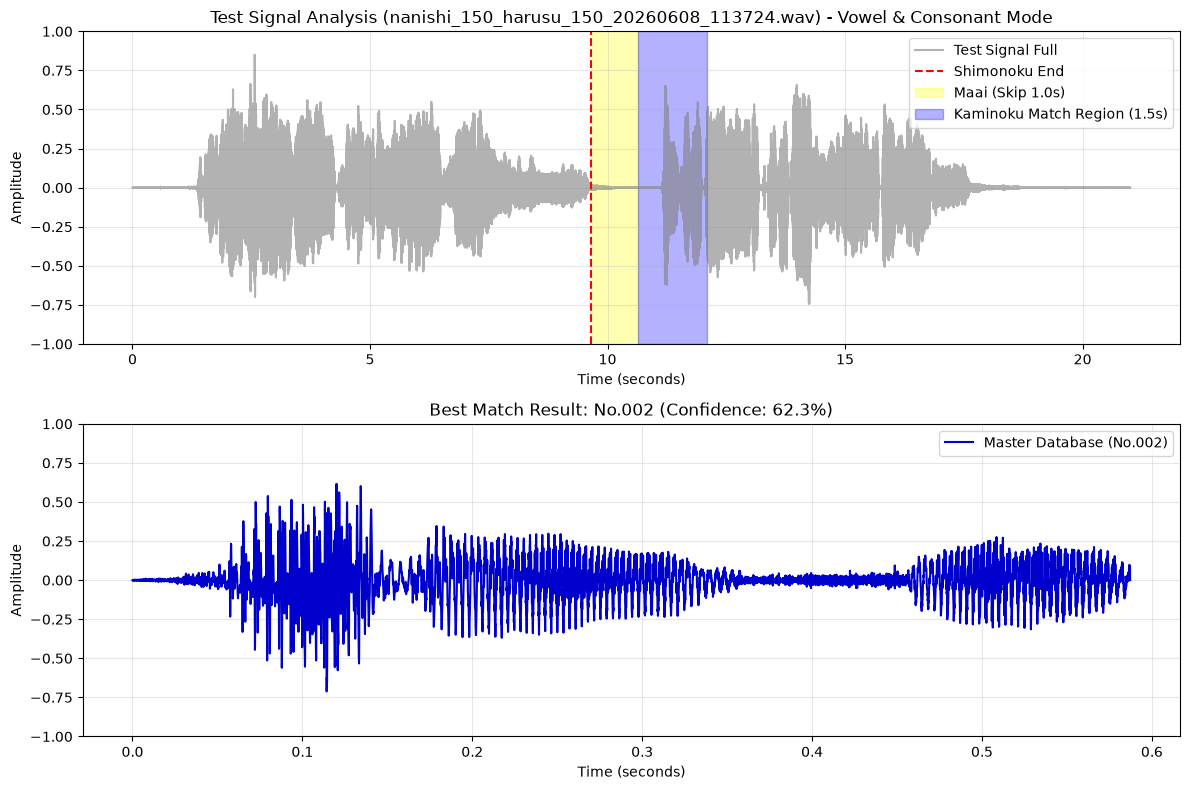


================ 札当て判定結果 ================
予想第1位  札番号: 002 (確信度: 62.3%)
予想第2位  札番号: 013 (確信度: 56.3%)
予想第3位  札番号: 022 (確信度: 54.7%)


: 

In [ ]:
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# ==========================================
# 設定エリア
# ==========================================
MASTER_DIR = "kimariji_database"       # 手動カットした100枚の上の句があるフォルダ
TEST_FILE = "nanishi_150_harusu_150_20260608_113724.wav"  # 解析したいテスト音声
#TEST_FILE = "nanishi_haruno_20260517_180128.wav"  # 解析したいテスト音声

VOLUME_THRESHOLD = 0.01                 # 下の句の音を感知するしきい値
WAIT_SECONDS = 0.75                      # 静寂が確定するまでの継続時間
MAAI_OFFSET = 1.0                       # 下の句終了後に機械的に飛ばす間合いの秒数
MATCH_DURATION = 1.45                    # 比較に使用する上の句の秒数

# ==========================================
# 1. 100枚のマスターデータの読み込み（子音＋母音抽出）
# ==========================================
print(f"--- {MASTER_DIR} から正解用のマスターデータを読み込み中 ---")
master_features = {}
master_signals = {}

for file_name in os.listdir(MASTER_DIR):
    if file_name.endswith("_u.wav"):
        file_path = os.path.join(MASTER_DIR, file_name)
        card_num = file_name.split("_")[0]
        
        try:
            y, sr = librosa.load(file_path, sr=16000, mono=True)
            mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, hop_length=160)
            mfcc_mean = np.mean(mfcc, axis=1)
            
            # 【改良】母音(1-4)と子音(9-12)の特徴量だけを結合して8次元にする
            vowel_part = mfcc_mean[1:5]
            consonant_part = mfcc_mean[9:13]
            vowel_consonant_vector = np.concatenate([vowel_part, consonant_part])
            
            master_features[card_num] = vowel_consonant_vector
            master_signals[card_num] = y
        except Exception as e:
            print(f"警告: マスター読み込み失敗 ({file_name}): {e}")

print(f"成功: マスターデータの準備完了 ({len(master_features)} 札分)\n")

# ==========================================
# 2. 下の句終了検知 および 上の句の機械的切り出し
# ==========================================
if not os.path.exists(TEST_FILE):
    print(f"エラー: テスト用の音声ファイル {TEST_FILE} が見つかりません。")
    exit()

print(f"--- テスト音声 {TEST_FILE} を解析中 ---")
y_test, sr_test = librosa.load(TEST_FILE, sr=16000, mono=True)

# RMS（音量）計算
hop_length_rms = 160
rms = librosa.feature.rms(y=y_test, hop_length=hop_length_rms)[0]
frames = range(len(rms))
times_rms = librosa.frames_to_time(frames, sr=sr_test, hop_length=hop_length_rms)

is_speaking = False
silence_start_time = None
shimo_end_time = None

for t, current_volume in zip(times_rms, rms):
    if current_volume > VOLUME_THRESHOLD:
        if not is_speaking:
            is_speaking = True
        silence_start_time = None
    else:
        if is_speaking:
            if silence_start_time is None:
                silence_start_time = t
            elif t - silence_start_time >= WAIT_SECONDS:
                shimo_end_time = silence_start_time
                break

if shimo_end_time is None:
    shimo_end_time = times_rms[-1] - WAIT_SECONDS

next_kami_start_time = shimo_end_time + MAAI_OFFSET
next_kami_end_time = next_kami_start_time + MATCH_DURATION

# 上の句のセグメントを抽出
start_sample = int(next_kami_start_time * sr_test)
end_sample = int(next_kami_end_time * sr_test)
y_kami_segment = y_test[start_sample:end_sample]

# ==========================================
# 3. 切り出した上の句と100枚のマスターを総当たり比較
# ==========================================
mfcc_test = librosa.feature.mfcc(y=y_kami_segment, sr=sr_test, n_mfcc=13, hop_length=160)
mfcc_test_mean = np.mean(mfcc_test, axis=1)

# 【改良】テスト音声側も同様に母音(1-4)と子音(9-12)だけを結合して8次元にする
vowel_part_test = mfcc_test_mean[1:5]
consonant_part_test = mfcc_test_mean[9:13]
vowel_consonant_vector_test = np.concatenate([vowel_part_test, consonant_part_test]).reshape(1, -1)

match_results = []
for card_num, master_vector in master_features.items():
    master_vector_reshaped = master_vector.reshape(1, -1)
    similarity = cosine_similarity(vowel_consonant_vector_test, master_vector_reshaped)[0][0]
    match_results.append((card_num, similarity))

match_results = sorted(match_results, key=lambda x: x[1], reverse=True)
best_card_num = match_results[0][0]

# ==========================================
# 4. 結果のプロット表示
# ==========================================
times_test = np.linspace(0, len(y_test) / sr_test, len(y_test))

plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(times_test, y_test, color="gray", alpha=0.6, label="Test Signal Full")
plt.axvline(x=shimo_end_time, color="red", linestyle="--", linewidth=1.5, label="Shimonoku End")
plt.axvspan(shimo_end_time, next_kami_start_time, color="yellow", alpha=0.3, label="Maai (Skip 1.0s)")
plt.axvspan(next_kami_start_time, next_kami_end_time, color="blue", alpha=0.3, label="Kaminoku Match Region (1.5s)")
plt.title(f"Test Signal Analysis ({TEST_FILE}) - Vowel & Consonant Mode")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.ylim(-1.0, 1.0)
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
y_master = master_signals[best_card_num]
times_master = np.linspace(0, len(y_master) / sr_test, len(y_master))
plt.plot(times_master, y_master, color="mediumblue", label=f"Master Database (No.{best_card_num})")
plt.title(f"Best Match Result: No.{best_card_num} (Confidence: {match_results[0][1]*100:.1f}%)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.ylim(-1.0, 1.0)
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n================ 札当て判定結果 ================")
print(f"予想第1位  札番号: {match_results[0][0]} (確信度: {match_results[0][1]*100:.1f}%)")
print(f"予想第2位  札番号: {match_results[1][0]} (確信度: {match_results[1][1]*100:.1f}%)")
print(f"予想第3位  札番号: {match_results[2][0]} (確信度: {match_results[2][1]*100:.1f}%)")
print("==================================================")

RMS波形表示専用

--- 音声ファイル nanishi_150_harusu_150_20260608_113724.wav を解析中 ---


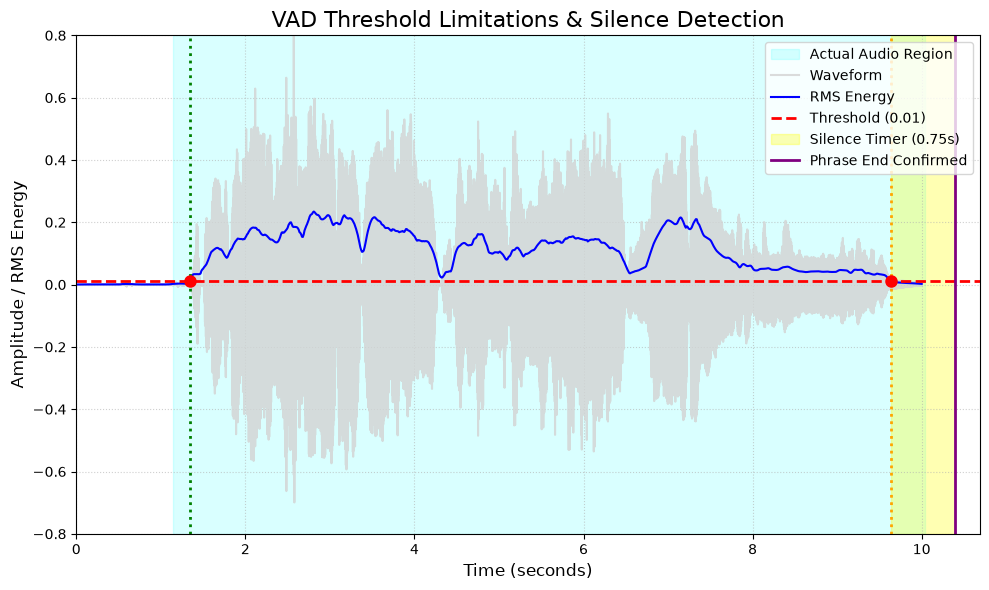

In [11]:
import numpy as np
import librosa
import matplotlib.pyplot as plt

# ==========================================
# 設定エリア
# ==========================================
TEST_FILE = "nanishi_150_harusu_150_20260608_113724.wav" 

VOLUME_THRESHOLD = 0.01  # 音を感知するしきい値
HOP_LENGTH_RMS = 160     # RMSを計算するフレーム幅
WAIT_SECONDS = 0.75      # この秒数無音が続いたら「間合い」と判定

Y_LIMIT = 0.8            # 波形の縦ズーム調整

# ==========================================
# 1. 音声の読み込みとRMS計算
# ==========================================
print(f"--- 音声ファイル {TEST_FILE} を解析中 ---")
try:
    y_test, sr_test = librosa.load(TEST_FILE, sr=16000, mono=True, duration=10.0)
except Exception as e:
    print(f"エラー: 音声ファイルの読み込みに失敗しました。\n詳細: {e}")
    exit()

rms = librosa.feature.rms(y=y_test, hop_length=HOP_LENGTH_RMS)[0]
frames = range(len(rms))
times_rms = librosa.frames_to_time(frames, sr=sr_test, hop_length=HOP_LENGTH_RMS)
times_test = np.linspace(0, len(y_test) / sr_test, len(y_test))

# ==========================================
# 2. 音の検知と「間合い」での打ち切り処理
# ==========================================
is_speaking = False
first_detect_time = None
last_detect_time = None
silence_start_time = None
shimo_end_time = None

for t, current_volume in zip(times_rms, rms):
    if current_volume > VOLUME_THRESHOLD:
        if not is_speaking:
            is_speaking = True
            if first_detect_time is None:
                first_detect_time = t
        
        last_detect_time = t
        silence_start_time = None
        
    else:
        if is_speaking:
            if silence_start_time is None:
                silence_start_time = t
            elif t - silence_start_time >= WAIT_SECONDS:
                shimo_end_time = last_detect_time 
                break

if shimo_end_time is None:
    shimo_end_time = last_detect_time if last_detect_time else times_rms[-1]

# ★ 実際の音声が存在する範囲（水色）の設定
# 最初の赤丸より「少し前」から始まり、最後の赤丸を越えて「黄色いエリアに食い込む」ように設定します
# ※お使いの音声波形（グレーのギザギザ）の実際の見た目に合わせて微調整してください
ACTUAL_SOUND_START = max(0, first_detect_time - 0.2) if first_detect_time else 0.5
ACTUAL_SOUND_END = shimo_end_time + 0.4  # 黄色いエリア（0.75秒間）の途中まで余韻が続いている想定

# ==========================================
# 3. グラフの描画
# ==========================================
# ★ 横幅を少し縮めてスライドに収まりやすくしました（10, 6）
plt.figure(figsize=(10, 6))

# 実際の音声が存在する範囲（水色）
plt.axvspan(ACTUAL_SOUND_START, ACTUAL_SOUND_END, color="cyan", alpha=0.15, label="Actual Audio Region")

# 元の音声波形
plt.plot(times_test, y_test, color="lightgray", alpha=0.8, label="Waveform")

# RMSエネルギー
plt.plot(times_rms, rms, color="blue", linewidth=1.5, label="RMS Energy")

# 閾値のライン
plt.axhline(y=VOLUME_THRESHOLD, color="red", linestyle="--", linewidth=2, label=f"Threshold ({VOLUME_THRESHOLD})")

# 最初の検知ポイント（立ち上がり）
if first_detect_time:
    plt.axvline(x=first_detect_time, color="green", linestyle=":", linewidth=2)
    plt.plot(first_detect_time, VOLUME_THRESHOLD, marker='o', markersize=8, color="red", zorder=5)

# 最後の検知ポイント（立ち下がり）
if last_detect_time:
    plt.axvline(x=last_detect_time, color="orange", linestyle=":", linewidth=2)
    plt.plot(last_detect_time, VOLUME_THRESHOLD, marker='o', markersize=8, color="red", zorder=5)

# 間合い検知ゾーン
plt.axvspan(shimo_end_time, shimo_end_time + WAIT_SECONDS, color="yellow", alpha=0.3, label=f"Silence Timer ({WAIT_SECONDS}s)")
plt.axvline(x=shimo_end_time + WAIT_SECONDS, color="purple", linestyle="-", linewidth=2, label="Phrase End Confirmed")

plt.title("VAD Threshold Limitations & Silence Detection", fontsize=16)
plt.xlabel("Time (seconds)", fontsize=12)
plt.ylabel("Amplitude / RMS Energy", fontsize=12)
plt.legend(loc="upper right", fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)

plt.ylim(-Y_LIMIT, Y_LIMIT)
plt.xlim(0, shimo_end_time + WAIT_SECONDS + 0.3)

plt.tight_layout()
plt.show()

音声波形

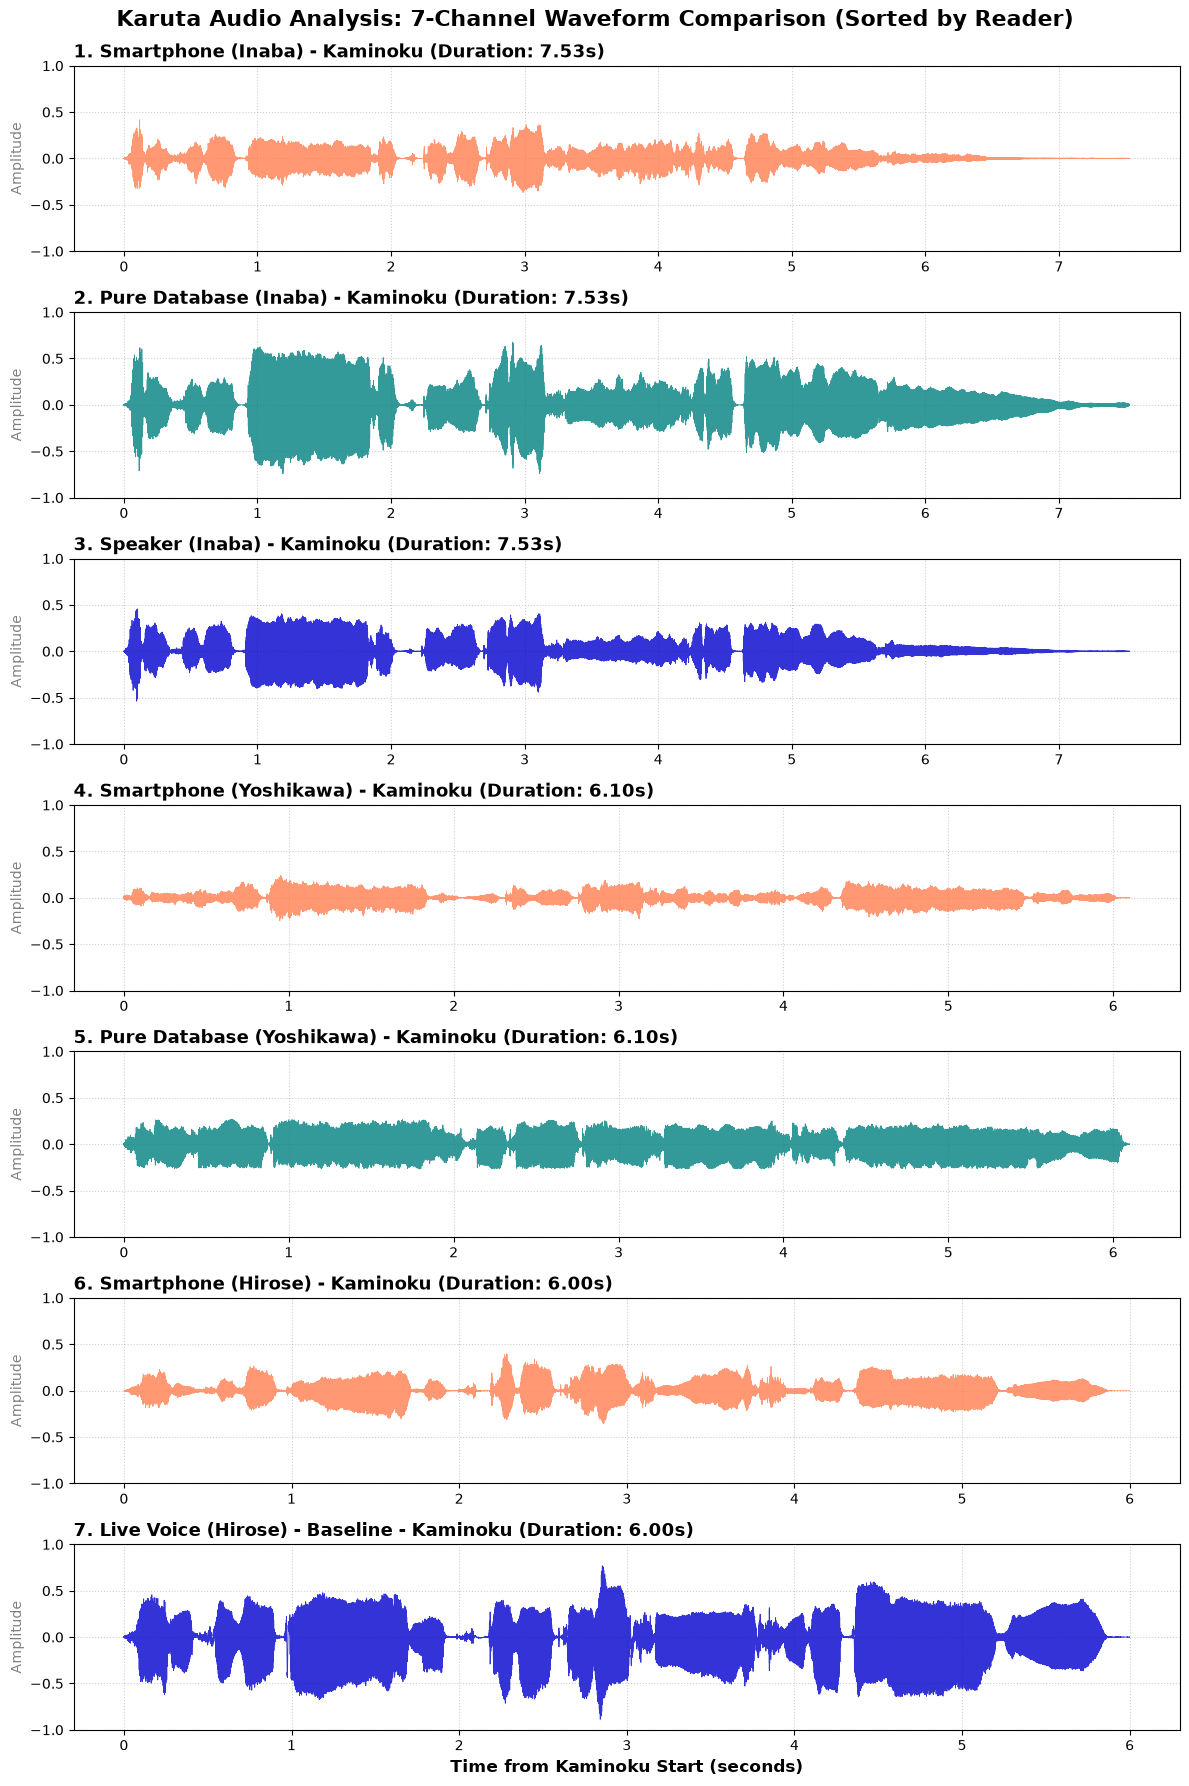

In [11]:
import numpy as np
import librosa
import matplotlib.pyplot as plt
import warnings

# 警告非表示
warnings.filterwarnings("ignore")

# ==========================================
# 1. 設定エリア（稲葉 ➔ 吉川 ➔ 廣瀨 の順に並び替え）
# ==========================================
AUDIO_FILES = [
    # --- 稲葉読手 ---
    r"C:\Users\misak\Desktop\karuta_vosk\recordings\nanishi_harusu_20260519_170920.wav",      # 1. スマホ: 稲葉
    r"C:\Users\misak\Desktop\karuta_vosk\karuta_database\002_u.wav",                              # 2. DB生声: 稲葉
    r"C:\Users\misak\Desktop\karuta_vosk\inaba_harusu_20260628_151052.wav",                       # 3. スピーカー: 稲葉
    
    # --- 吉川読手 ---
    r"C:\Users\misak\Desktop\karuta_vosk\recordings\nanishi_jito_harusu_yosikawa_20260519_165826.wav",  # 4. スマホ: 吉川
    r"C:\Users\misak\Desktop\karuta_vosk\yoshikawa_harusu.wav",                                  # 5. DB生声: 吉川
    
    # --- 廣瀨読手 ---
    r"C:\Users\misak\Desktop\karuta_vosk\recordings\harusu_hito_harusuhito__20260525_224801.wav",   # 6. スマホ: 廣瀨
    r"C:\Users\misak\Desktop\karuta_vosk\recordings\nanishi_hito_harusu_hito_20260519_165551.wav"       # 7. 生の声: 廣瀨
]

TITLES = [
    "1. Smartphone (Inaba)",
    "2. Pure Database (Inaba)",
    "3. Speaker (Inaba)",
    "4. Smartphone (Yoshikawa)",
    "5. Pure Database (Yoshikawa)",
    "6. Smartphone (Hirose)",
    "7. Live Voice (Hirose) - Baseline"
]

CROP_REGIONS = [
    # --- 稲葉読手 ---
    {"start": 15.0, "end": 22.53},  # 1. 稲葉スマホ
    {"start": 0.0,  "end": -1},    # 2. 稲葉DB (まるごと)
    {"start": 0.5,  "end": 8.03},   # 3. 稲葉スピーカー
    
    # --- 吉川読手 ---
    {"start": 12.6, "end": 18.7},  # 4. 吉川スマホ
    {"start": 0.4,  "end": 6.5},   # 5. 吉川DB
    
    # --- 廣瀨読手 ---
    {"start": 19.0, "end": 25.0},  # 6. 廣瀨スマホ
    {"start": 10.9, "end": 16.9}   # 7. 廣瀨生声
]

SAMPLERATE = 16000

# ==========================================
# 2. グラフ描画
# ==========================================
# 固定値「6」から「len(AUDIO_FILES)」（7行）に動的変更してエラーを回避
fig, axes = plt.subplots(len(AUDIO_FILES), 1, figsize=(12, 18), sharex=False)

# 万が一ファイル数が1つだった場合の配列固定化処理
if len(AUDIO_FILES) == 1:
    axes = [axes]

for i, (audio_path, title, region) in enumerate(zip(AUDIO_FILES, TITLES, CROP_REGIONS)):
    ax = axes[i]
    
    try:
        # 音声読み込み
        y, sr = librosa.load(audio_path, sr=SAMPLERATE, mono=True)
        
        # 秒数をサンプル数に変換
        start_sample = int(region["start"] * sr)
        if region["end"] == -1:
            end_sample = len(y)
        else:
            end_sample = int(region["end"] * sr)
        
        # 指定区間を切り出し
        y_cut = y[start_sample:end_sample]
        times_cut = np.linspace(0, len(y_cut) / sr, len(y_cut))
        
        # 色分け設定（スマホ＝コーラル、生・DB＝青系）
        if "Smartphone" in title:
            plot_color = "coral"
        elif "Database" in title:
            plot_color = "teal"
        else:
            plot_color = "mediumblue"
            
        ax.plot(times_cut, y_cut, color=plot_color, alpha=0.8, linewidth=0.6)
        ax.set_ylim(-1.0, 1.0)
        ax.set_ylabel("Amplitude", color="gray")
        ax.grid(True, linestyle=":", alpha=0.6)
        
        # タイトルに切り出し後の純粋な秒数を表示
        duration = len(y_cut) / sr
        ax.set_title(f"{title} - Kaminoku (Duration: {duration:.2f}s)", fontsize=13, fontweight="bold", loc="left")
        
    except Exception as e:
        ax.set_title(f"{title} - [エラー: {e}]", color="red", loc="left")

# 最下部の軸ラベルと全体のメインタイトルを設定
axes[-1].set_xlabel("Time from Kaminoku Start (seconds)", fontsize=12, fontweight="bold")
# タイトル内の「6-Channel」も実態に合わせて「7-Channel」へ修正
plt.suptitle("Karuta Audio Analysis: 7-Channel Waveform Comparison (Sorted by Reader)", fontsize=16, fontweight="bold", y=0.99)
plt.tight_layout()
plt.show()

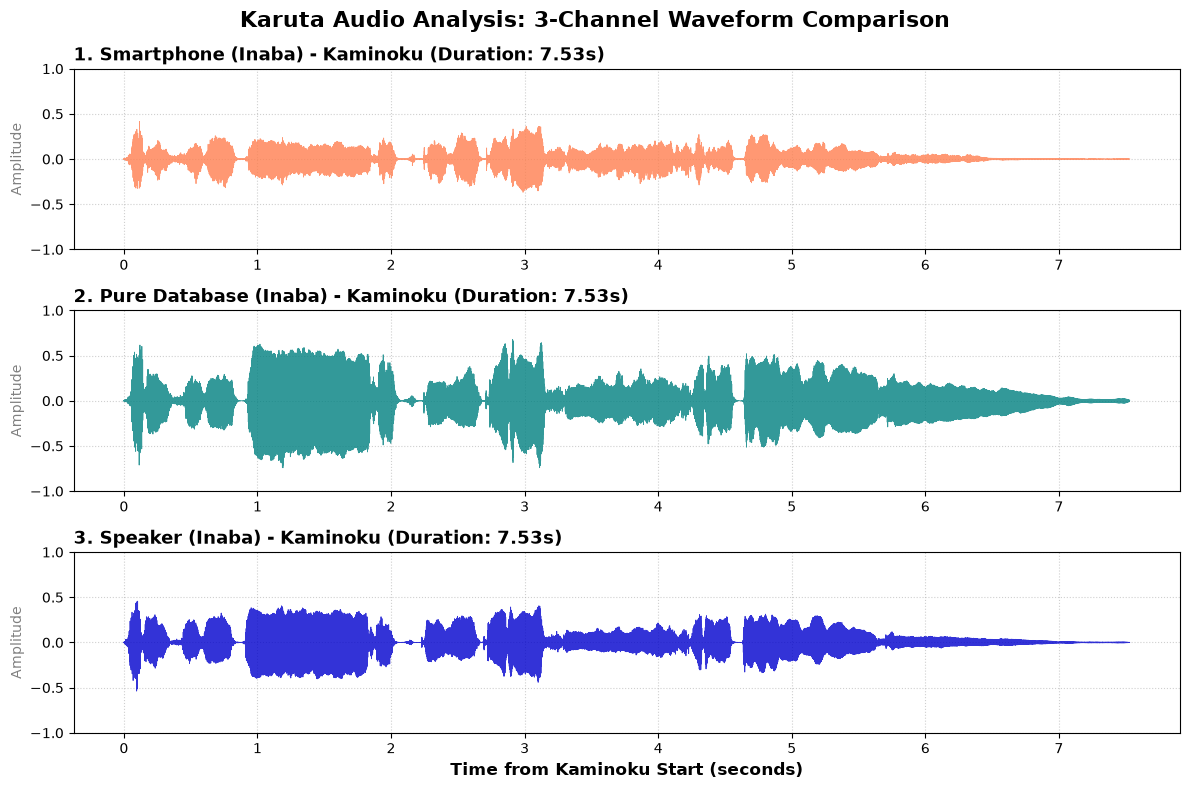

In [15]:
import numpy as np
import librosa
import matplotlib.pyplot as plt
import warnings

# 警告非表示
warnings.filterwarnings("ignore")

# ==========================================
# 1. 設定エリア（稲葉読手・3ファイル構成）
# ==========================================
AUDIO_FILES = [
    # --- 稲葉読手 ---
    r"C:\Users\misak\Desktop\karuta_vosk\recordings\nanishi_harusu_20260519_170920.wav",      # 1. スマホ: 稲葉
    r"C:\Users\misak\Desktop\karuta_vosk\karuta_database\002_u.wav",                              # 2. DB生声: 稲葉
    r"C:\Users\misak\Desktop\karuta_vosk\inaba_harusu_20260628_151052.wav"                       # 3. スピーカー: 稲葉
]

TITLES = [
    "1. Smartphone (Inaba)",
    "2. Pure Database (Inaba)",
    "3. Speaker (Inaba)"
]

CROP_REGIONS = [
    {"start": 15.0, "end": 22.53},  # 1. 稲葉スマホ
    {"start": 0.0,  "end": -1},     # 2. 稲葉DB (まるごと)
    {"start": 0.5,  "end": 8.03}    # 3. 稲葉スピーカー
]

SAMPLERATE = 16000

# ==========================================
# 2. グラフ描画
# ==========================================
# 3つのグラフが綺麗に収まるよう、高さを18から「8」に調整
fig, axes = plt.subplots(len(AUDIO_FILES), 1, figsize=(12, 8), sharex=False)

# 万が一ファイル数が1つだった場合の配列固定化処理
if len(AUDIO_FILES) == 1:
    axes = [axes]

for i, (audio_path, title, region) in enumerate(zip(AUDIO_FILES, TITLES, CROP_REGIONS)):
    ax = axes[i]
    
    try:
        # 音声読み込み
        y, sr = librosa.load(audio_path, sr=SAMPLERATE, mono=True)
        
        # 秒数をサンプル数に変換
        start_sample = int(region["start"] * sr)
        if region["end"] == -1:
            end_sample = len(y)
        else:
            end_sample = int(region["end"] * sr)
        
        # 指定区間を切り出し
        y_cut = y[start_sample:end_sample]
        times_cut = np.linspace(0, len(y_cut) / sr, len(y_cut))
        
        # 色分け設定（スマホ＝コーラル、生・DB＝青系）
        if "Smartphone" in title:
            plot_color = "coral"
        elif "Database" in title:
            plot_color = "teal"
        else:
            plot_color = "mediumblue"
            
        ax.plot(times_cut, y_cut, color=plot_color, alpha=0.8, linewidth=0.6)
        ax.set_ylim(-1.0, 1.0)
        ax.set_ylabel("Amplitude", color="gray")
        ax.grid(True, linestyle=":", alpha=0.6)
        
        # タイトルに切り出し後の純粋な秒数を表示
        duration = len(y_cut) / sr
        ax.set_title(f"{title} - Kaminoku (Duration: {duration:.2f}s)", fontsize=13, fontweight="bold", loc="left")
        
    except Exception as e:
        ax.set_title(f"{title} - [エラー: {e}]", color="red", loc="left")

# 最下部の軸ラベルと全体のメインタイトルを設定
axes[-1].set_xlabel("Time from Kaminoku Start (seconds)", fontsize=12, fontweight="bold")
plt.suptitle("Karuta Audio Analysis: 3-Channel Waveform Comparison", fontsize=16, fontweight="bold", y=0.98)
plt.tight_layout()
plt.show()

ゲイン調整

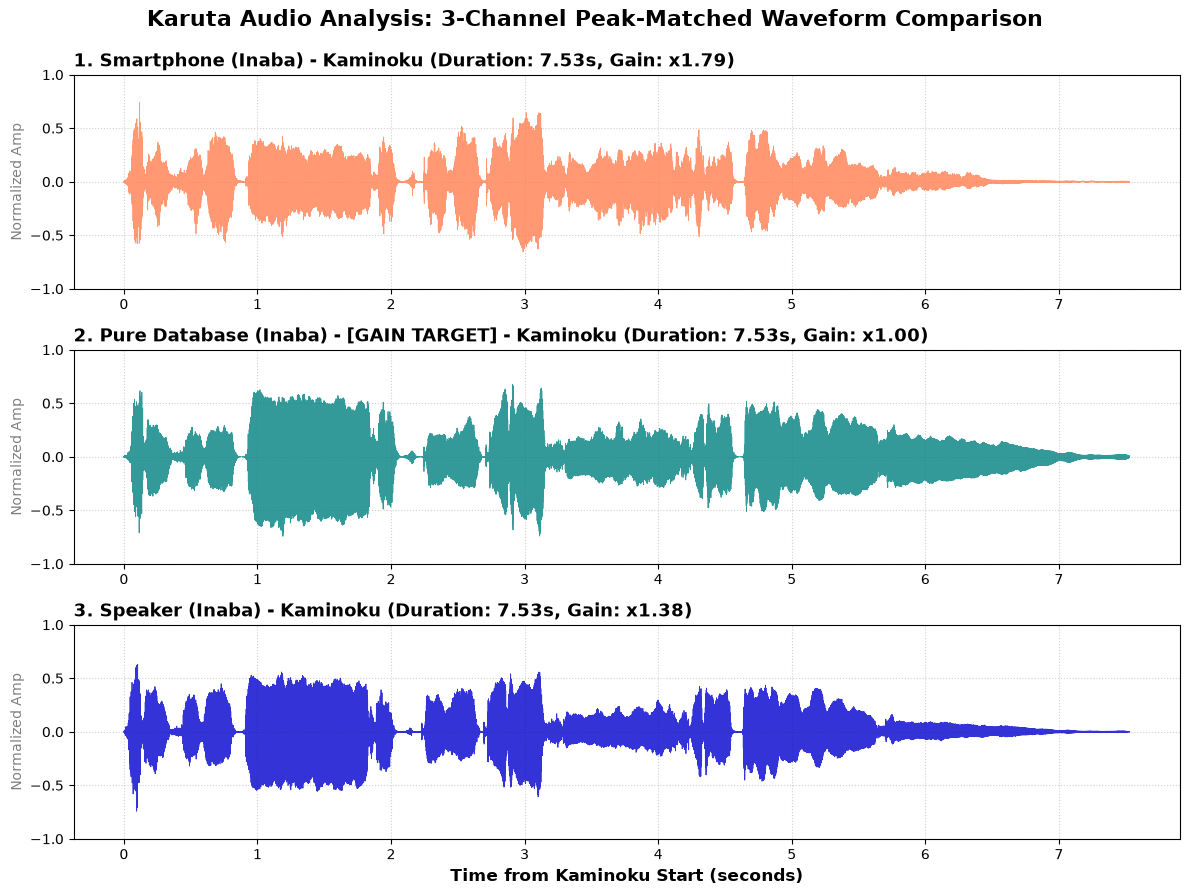

In [14]:
import numpy as np
import librosa
import matplotlib.pyplot as plt
import warnings

# 警告非表示
warnings.filterwarnings("ignore")

# ==========================================
# 1. 設定エリア（稲葉読手のみに絞り込み）
# ==========================================
AUDIO_FILES = [
    # --- 稲葉読手 ---
    r"C:\Users\misak\Desktop\karuta_vosk\recordings\nanishi_harusu_20260519_170920.wav",      # 1. スマホ: 稲葉
    r"C:\Users\misak\Desktop\karuta_vosk\karuta_database\002_u.wav",                              # 2. DB生声: 稲葉（★基準ターゲット）
    r"C:\Users\misak\Desktop\karuta_vosk\inaba_harusu_20260628_151052.wav"                       # 3. スピーカー: 稲葉
]

TITLES = [
    "1. Smartphone (Inaba)",
    "2. Pure Database (Inaba) - [GAIN TARGET]",
    "3. Speaker (Inaba)"
]

CROP_REGIONS = [
    {"start": 15.0, "end": 22.53},  # 1. 稲葉スマホ
    {"start": 0.0,  "end": -1},    # 2. 稲葉DB
    {"start": 0.5,  "end": 8.03}    # 3. 稲葉スピーカー
]

SAMPLERATE = 16000
TARGET_DB_INDEX = 1 # AUDIO_FILES[1]（Pure Database）を基準にする

# ==========================================
# 2. データの事前読み込み & 基準ゲインの算出
# ==========================================
loaded_cuts = []
max_amplitudes = []

for audio_path, region in zip(AUDIO_FILES, CROP_REGIONS):
    try:
        y, sr = librosa.load(audio_path, sr=SAMPLERATE, mono=True)
        start_sample = int(region["start"] * sr)
        end_sample = len(y) if region["end"] == -1 else int(region["end"] * sr)
        y_cut = y[start_sample:end_sample]
        
        loaded_cuts.append(y_cut)
        # 絶対値の最大（ピーク値）を記録（ゼロ除算防止に微小値を加算）
        max_amplitudes.append(np.max(np.abs(y_cut)) + 1e-8)
    except Exception as e:
        loaded_cuts.append(None)
        max_amplitudes.append(None)

# 基準となるPure Databaseの最大音量を取得
target_peak = max_amplitudes[TARGET_DB_INDEX] if max_amplitudes[TARGET_DB_INDEX] is not None else 1.0

# ==========================================
# 3. グラフ描画（3ファイルに合わせて高さを 9 に調整）
# ==========================================
fig, axes = plt.subplots(len(AUDIO_FILES), 1, figsize=(12, 9), sharex=False)

if len(AUDIO_FILES) == 1:
    axes = [axes]

for i, (title, y_cut, current_peak) in enumerate(zip(TITLES, loaded_cuts, max_amplitudes)):
    ax = axes[i]
    
    if y_cut is None:
        ax.set_title(f"{title} - [エラー: 音声ファイルの読み込みに失敗しました]", color="red", loc="left")
        continue
        
    try:
        # --- ゲイン自動調整処理 ---
        # 自身を基準に合わせるための倍率（ゲイン係数）を計算
        gain_factor = target_peak / current_peak
        y_scaled = y_cut * gain_factor
        
        times_cut = np.linspace(0, len(y_scaled) / SAMPLERATE, len(y_scaled))
        
        # 色分け設定
        if "Smartphone" in title:
            plot_color = "coral"
        elif "Database" in title:
            plot_color = "teal"
        else:
            plot_color = "mediumblue"
            
        ax.plot(times_cut, y_scaled, color=plot_color, alpha=0.8, linewidth=0.6)
        ax.set_ylim(-1.0, 1.0)
        ax.set_ylabel("Normalized Amp", color="gray")
        ax.grid(True, linestyle=":", alpha=0.6)
        
        duration = len(y_scaled) / SAMPLERATE
        # タイトルに調整したゲイン倍率（x1.25など）を追記して分かりやすく
        ax.set_title(f"{title} - Kaminoku (Duration: {duration:.2f}s, Gain: x{gain_factor:.2f})", fontsize=13, fontweight="bold", loc="left")
        
    except Exception as e:
        ax.set_title(f"{title} - [エラー: {e}]", color="red", loc="left")

axes[-1].set_xlabel("Time from Kaminoku Start (seconds)", fontsize=12, fontweight="bold")
plt.suptitle("Karuta Audio Analysis: 3-Channel Peak-Matched Waveform Comparison", fontsize=16, fontweight="bold", y=0.99)
plt.tight_layout()
plt.show()

スペクトログラム

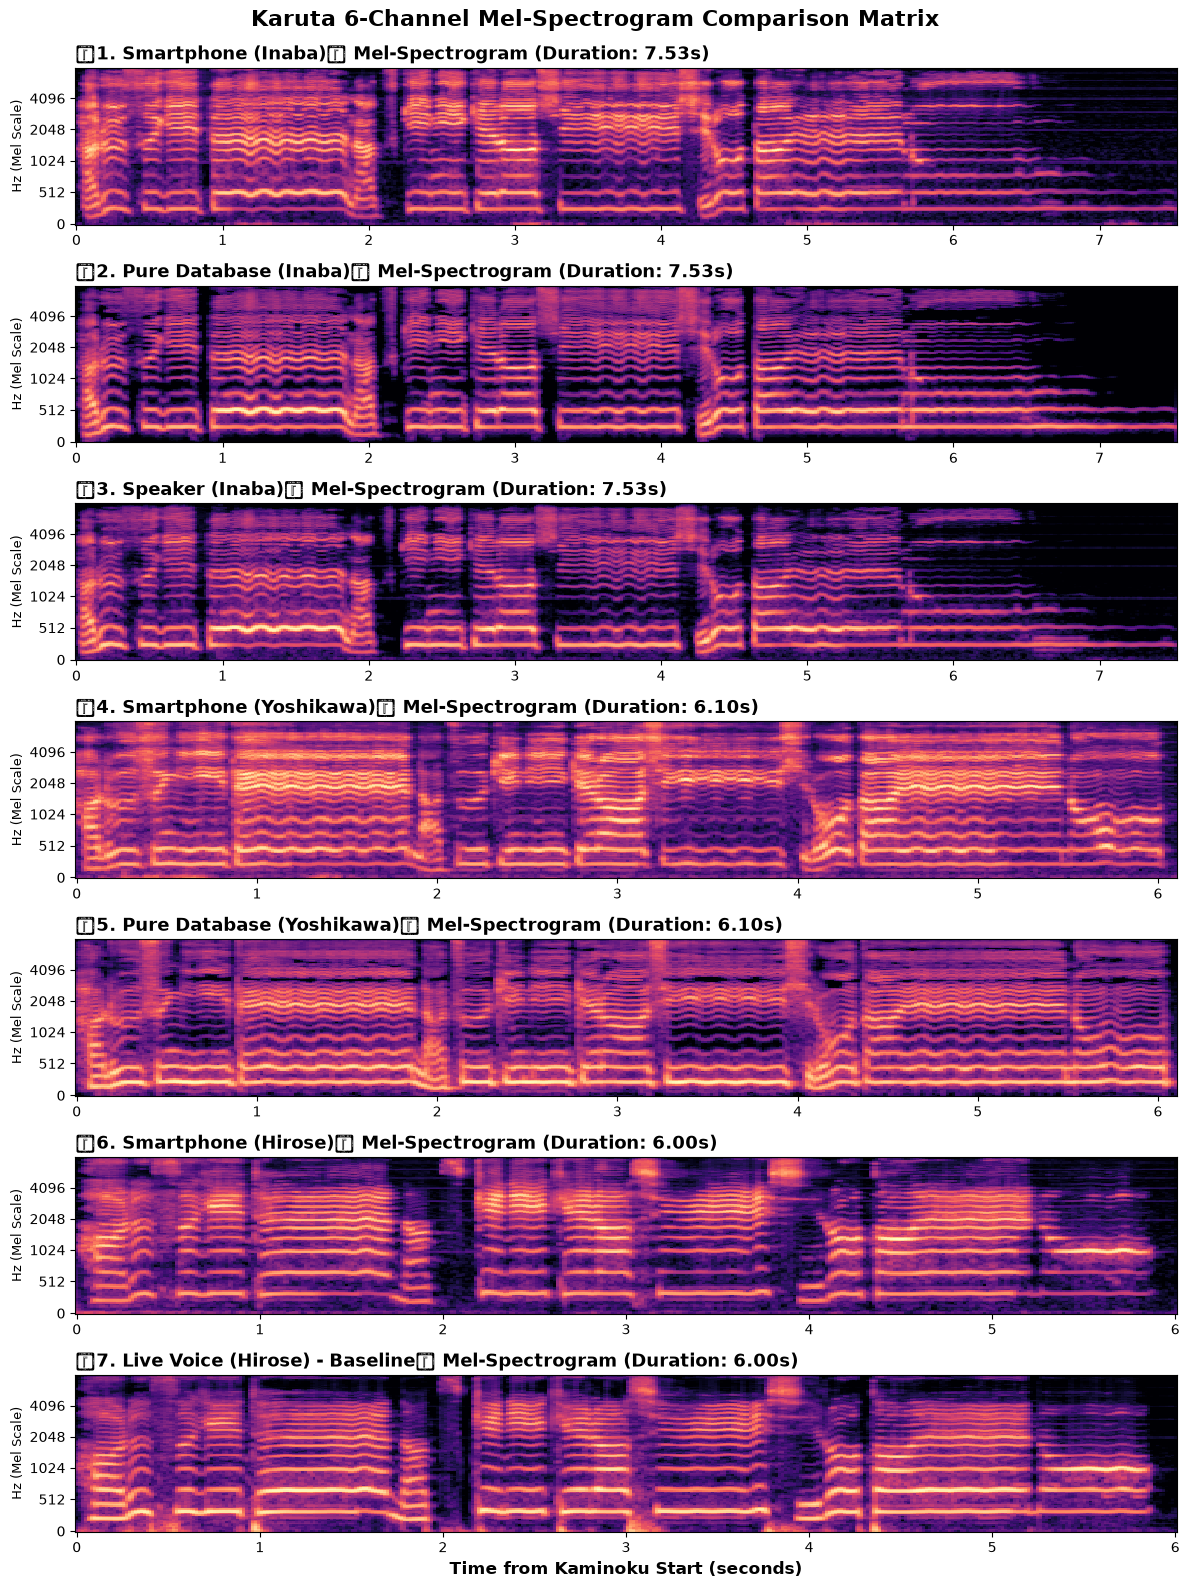

In [5]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import warnings

# 警告非表示
warnings.filterwarnings("ignore")

# ==========================================
# 1. 設定エリア（稲葉 ➔ 吉川 ➔ 廣瀨 の順）
# ==========================================
AUDIO_FILES = [
    # --- 稲葉読手 ---
    r"C:\Users\misak\Desktop\karuta_vosk\recordings\nanishi_harusu_20260519_170920.wav",      # 1. スマホ: 稲葉
    r"C:\Users\misak\Desktop\karuta_vosk\karuta_database\002_u.wav",                              # 2. DB生声: 稲葉
    r"C:\Users\misak\Desktop\karuta_vosk\inaba_harusu_20260628_151052.wav",
    
    # --- 吉川読手 ---
    r"C:\Users\misak\Desktop\karuta_vosk\recordings\nanishi_jito_harusu_yosikawa_20260519_165826.wav",  # 4. スマホ: 吉川
    r"C:\Users\misak\Desktop\karuta_vosk\yoshikawa_harusu.wav",                                  # 5. DB生声: 吉川
    
    # --- 廣瀨読手 ---
    r"C:\Users\misak\Desktop\karuta_vosk\recordings\harusu_hito_harusuhito__20260525_224801.wav",   # 6. スマホ: 廣瀨
    r"C:\Users\misak\Desktop\karuta_vosk\recordings\nanishi_hito_harusu_hito_20260519_165551.wav"      # 7. 生の声: 廣瀨
]

TITLES = [
    "1. Smartphone (Inaba)",
    "2. Pure Database (Inaba)",
    "3. Speaker (Inaba)",
    "4. Smartphone (Yoshikawa)",
    "5. Pure Database (Yoshikawa)",
    "6. Smartphone (Hirose)",
    "7. Live Voice (Hirose) - Baseline"
]

CROP_REGIONS = [
    # --- 稲葉読手 ---
    {"start": 15.0, "end": 22.53},  # 1. 稲葉スマホ
    {"start": 0.0,  "end": -1},    # 2. 稲葉DB (まるごと)
    {"start": 0.5,  "end": 8.03},    # 3. 稲葉スピーカー (まるごと)

    # --- 吉川読手 ---
    {"start": 12.6, "end": 18.7},  # 4. 吉川スマホ
    {"start": 0.4,  "end": 6.5},    # 5. 吉川DB (まるごと)
    
    # --- 廣瀨読手 ---
    {"start": 19.0, "end": 25.0},  # 6. 廣瀨スマホ
    {"start": 10.9, "end": 16.9}   # 7. 廣瀨生声
]

SAMPLERATE = 16000

# ==========================================
# 2. グラフ描画（6ファイル × 1プロット = 6行）
# ==========================================
# スペクトログラムだけに絞ったため、画面サイズをすっきり縦長（12, 16）に調整
fig, axes = plt.subplots(len(AUDIO_FILES), 1, figsize=(12, 16), sharex=False)

for i, (audio_path, title, region) in enumerate(zip(AUDIO_FILES, TITLES, CROP_REGIONS)):
    ax_spec = axes[i]
    
    try:
        # 音声読み込み
        y, sr = librosa.load(audio_path, sr=SAMPLERATE, mono=True)
        
        # 秒数をサンプル数に変換
        start_sample = int(region["start"] * sr)
        if region["end"] == -1:
            end_sample = len(y)
        else:
            end_sample = int(region["end"] * sr)
        
        # 指定区間を切り出し
        y_cut = y[start_sample:end_sample]
        
        # --- メルスペクトログラムの計算 ---
        # 窓幅1024、ズレ幅256で時間解像度を確保
        S = librosa.feature.melspectrogram(y=y_cut, sr=sr, n_fft=1024, hop_length=256)
        S_dB = librosa.power_to_db(S, ref=np.max) # 対数パワー（デシベル）に変換
        
        # 描画（マグマカラーで明暗をくっきり可視化）
        img = librosa.display.specshow(S_dB, sr=sr, hop_length=256, x_axis='time', y_axis='mel', ax=ax_spec, cmap='magma')
        
        # 各プロットの装飾
        duration = len(y_cut) / sr
        ax_spec.set_title(f"【{title}】 Mel-Spectrogram (Duration: {duration:.2f}s)", fontsize=13, fontweight="bold", loc="left")
        ax_spec.set_ylabel("Hz (Mel Scale)", fontsize=9)
        
        # 最後のプロットだけ下部に時間軸のラベルを表示
        if i == len(AUDIO_FILES) - 1:
            ax_spec.set_xlabel("Time from Kaminoku Start (seconds)", fontsize=12, fontweight="bold")
        else:
            ax_spec.set_xlabel("")
            
    except Exception as e:
        ax_spec.text(0.5, 0.5, f"【{title}】\n[エラー: {e}]", ha='center', va='center', color='red', fontsize=12)

plt.suptitle("Karuta 6-Channel Mel-Spectrogram Comparison Matrix", fontsize=16, fontweight="bold", y=0.99)
plt.tight_layout()
plt.show()

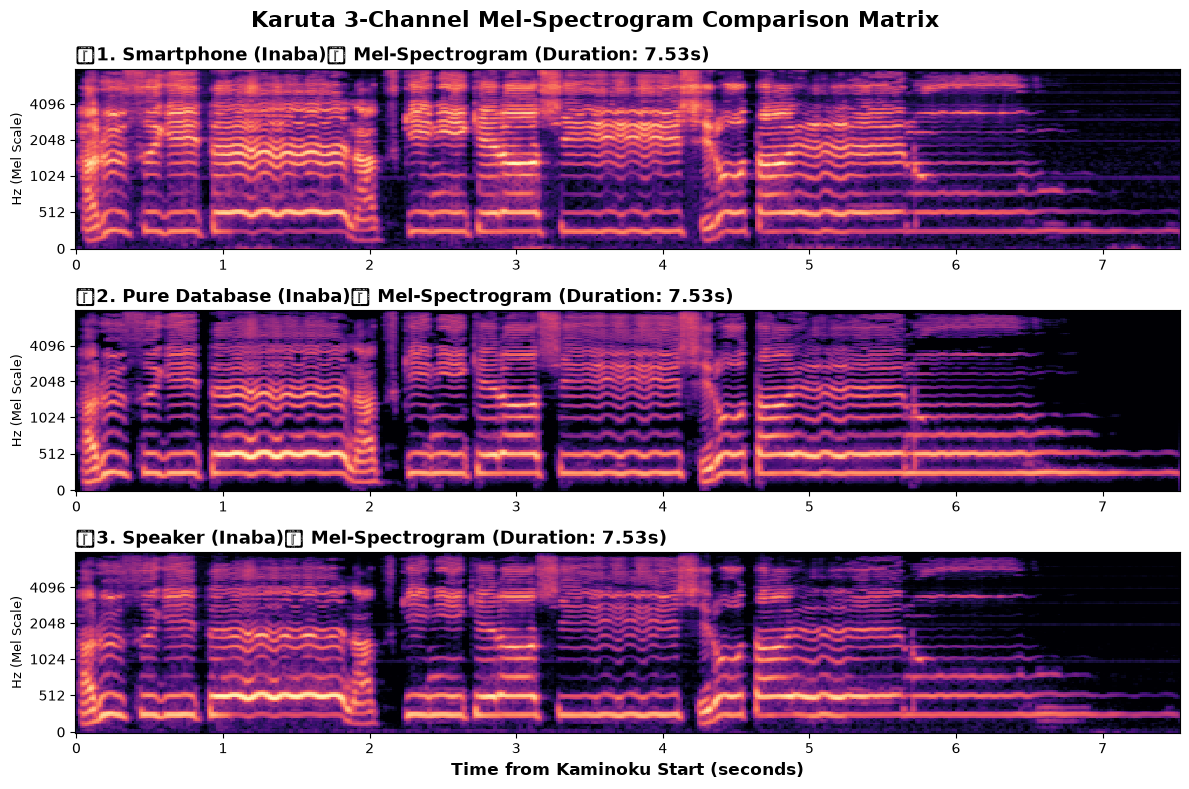

In [16]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import warnings

# 警告非表示
warnings.filterwarnings("ignore")

# ==========================================
# 1. 設定エリア（稲葉読手・3ファイル構成）
# ==========================================
AUDIO_FILES = [
    # --- 稲葉読手 ---
    r"C:\Users\misak\Desktop\karuta_vosk\recordings\nanishi_harusu_20260519_170920.wav",      # 1. スマホ: 稲葉
    r"C:\Users\misak\Desktop\karuta_vosk\karuta_database\002_u.wav",                              # 2. DB生声: 稲葉
    r"C:\Users\misak\Desktop\karuta_vosk\inaba_harusu_20260628_151052.wav"                       # 3. スピーカー: 稲葉 (★末尾にカンマ補正)
]

TITLES = [
    "1. Smartphone (Inaba)",
    "2. Pure Database (Inaba)",
    "3. Speaker (Inaba)"
]

CROP_REGIONS = [
    {"start": 15.0, "end": 22.53},  # 1. 稲葉スマホ
    {"start": 0.0,  "end": -1},     # 2. 稲葉DB (まるごと)
    {"start": 0.5,  "end": 8.03}    # 3. 稲葉スピーカー (まるごと)
]

SAMPLERATE = 16000

# ==========================================
# 2. グラフ描画
# ==========================================
# 3つのスペクトログラムが綺麗な比率で収まるよう、高さを16から「8」に調整
fig, axes = plt.subplots(len(AUDIO_FILES), 1, figsize=(12, 8), sharex=False)

# 万が一ファイル数が1つだった場合の配列固定化処理
if len(AUDIO_FILES) == 1:
    axes = [axes]

for i, (audio_path, title, region) in enumerate(zip(AUDIO_FILES, TITLES, CROP_REGIONS)):
    ax_spec = axes[i]
    
    try:
        # 音声読み込み
        y, sr = librosa.load(audio_path, sr=SAMPLERATE, mono=True)
        
        # 秒数をサンプル数に変換
        start_sample = int(region["start"] * sr)
        if region["end"] == -1:
            end_sample = len(y)
        else:
            end_sample = int(region["end"] * sr)
        
        # 指定区間を切り出し
        y_cut = y[start_sample:end_sample]
        
        # --- メルスペクトログラムの計算 ---
        S = librosa.feature.melspectrogram(y=y_cut, sr=sr, n_fft=1024, hop_length=256)
        S_dB = librosa.power_to_db(S, ref=np.max) # 対数パワー（デシベル）に変換
        
        # 描画（マグマカラーで明暗をくっきり可視化）
        img = librosa.display.specshow(S_dB, sr=sr, hop_length=256, x_axis='time', y_axis='mel', ax=ax_spec, cmap='magma')
        
        # 各プロットの装飾
        duration = len(y_cut) / sr
        ax_spec.set_title(f"【{title}】 Mel-Spectrogram (Duration: {duration:.2f}s)", fontsize=13, fontweight="bold", loc="left")
        ax_spec.set_ylabel("Hz (Mel Scale)", fontsize=9)
        
        # 最後のプロットだけ下部に時間軸のラベルを表示
        if i == len(AUDIO_FILES) - 1:
            ax_spec.set_xlabel("Time from Kaminoku Start (seconds)", fontsize=12, fontweight="bold")
        else:
            ax_spec.set_xlabel("")
            
    except Exception as e:
        ax_spec.text(0.5, 0.5, f"【{title}】\n[エラー: {e}]", ha='center', va='center', color='red', fontsize=12)

# タイトルを3-Channel用に更新
plt.suptitle("Karuta 3-Channel Mel-Spectrogram Comparison Matrix", fontsize=16, fontweight="bold", y=0.98)
plt.tight_layout()
plt.show()

音声の比較

In [83]:
import os
import wave
import json
import csv
import numpy as np
import matplotlib.pyplot as plt
from vosk import Model, KaldiRecognizer
import warnings

# 警告非表示
warnings.filterwarnings("ignore")

# ==========================================
# 1. 設定エリア
# ==========================================
CSV_FILE = "data/karuta_data.csv"
MODEL_PATH = "model_small"  # Voskのモデルがこのフォルダにある前提

AUDIO_FILES = [
    #r"C:\Users\misak\Desktop\karuta_vosk\yosikawa_harusu_20260519_165826.wav",     # 1. スマホ越し吉川
    #r"C:\Users\misak\Desktop\karuta_vosk\harusu_yosikawa_20260519_165826.wav",      # 1. スマホ越し吉川
    r"C:\Users\misak\Desktop\karuta_vosk\recordings\nanishi_jito_harusu_yosikawa_20260519_165826.wav",  # 1. スマホ越し吉川
    r"C:\Users\misak\Desktop\karuta_vosk\yoshikawa_harusu.wav",                  # 2. 生吉川
    r"C:\Users\misak\Desktop\karuta_vosk\inaba_harusu_20260616_174927.wav",       # 3. スマホ越し稲葉
    r"C:\Users\misak\Desktop\karuta_vosk\karuta_database\002_u.wav"              # 4. 生稲葉
]

TITLES = [
    "1. Smartphone (Yoshikawa)",
    "2. Database (Yoshikawa)",
    "3. Smartphone (Inaba)",
    "4. Database (Inaba)"
]

# 保存ファイル名の設定
TXT_REPORT_PATH = "karuta_recognition_report.txt"
PNG_REPORT_PATH = "karuta_score_comparison.png"

# ==========================================
# 2. 辞書ロジック（そのまま移植）
# ==========================================
def extract_kana_parts(text, pos_index):
    text = text.replace(" ", "")
    p = []
    L = len(text)
    if L < 2: return [text]
    if pos_index == 0 or pos_index >= 2:
        p.append(text[0:2])
        if L >= 4: p.append(text[2:4])
        if L >= 3: p.append(text[-3:])
        p.append(text[-2:])
    elif pos_index == 1:
        p.append(text[0:2])
        if L >= 4: p.append(text[2:4])
        if L >= 6: p.append(text[4:6])
        if L >= 7: p.append(text[-3:])
        if L >= 4: p.append(text[1:4])
        p.append(text[-2:])
    return p

def extract_kanji_parts(text):
    text = text.replace(" ", "")
    p = []
    if len(text) >= 2: p.append(text[:2])
    if len(text) >= 3: p.append(text[:3])
    if len(text) >= 2: p.append(text[-2:])
    if len(text) >= 3: p.append(text[-3:])
    return p

def prepare_karuta_system(file_path):
    if not os.path.exists(file_path):
        print(f"Error: {file_path} が見つかりません。")
        return None, None, None
    raw_cards = []
    with open(file_path, "r", encoding="utf-8-sig") as f:
        csv_reader = csv.reader(f)
        for row in csv_reader:
            if len(row) < 5: continue
            num, kanji, kana, kimari, gendai = [r.strip() for r in row[:5]]
            words = []; seen = set()
            def add_words(new_words, is_kimari=False):
                for w in new_words:
                    if w in seen: continue
                    if len(w) >= (1 if is_kimari else 2):
                        words.append(w); seen.add(w)
            add_words([kimari], is_kimari=True)
            add_words([gendai.replace(" ", "")])
            k_blocks = kanji.split(); h_blocks = kana.split()
            for i in range(max(len(k_blocks), len(h_blocks))):
                if i < len(k_blocks): add_words(extract_kanji_parts(k_blocks[i]))
                if i < len(h_blocks): add_words(extract_kana_parts(h_blocks[i], i))
            raw_cards.append({"num": num, "words": words})
    
    if not raw_cards: return None, None, None
    
    tag_map = {}; grammar_list = []; card_max_scores = {}
    for c in raw_cards:
        num = c["num"]
        unified_words = c["words"]
        total_potential = 0
        for w in unified_words:
            grammar_list.append(w)
            tag_map.setdefault(w, []).append(num)
            total_potential += len(w)
        card_max_scores[num] = total_potential
        
    return list(set(grammar_list)), tag_map, card_max_scores

# ==========================================
# 3. メイン処理開始
# ==========================================
grammar, tag_map, max_scores = prepare_karuta_system(CSV_FILE)
if not tag_map:
    print("カルタデータの読み込みに失敗したため終了します。")
    exit(1)

if not os.path.exists(MODEL_PATH):
    print(f"エラー: Voskのモデルが {MODEL_PATH} に見つかりません。")
    exit(1)

model = Model(MODEL_PATH)

# テキストレポート用のログを溜めるリスト
report_lines = []
def log_print(text):
    """画面に出力しつつ、レポート用バッファにも保存する関数"""
    print(text)
    report_lines.append(text)

log_print("\n--- WAVファイル一括判定処理開始 ---")

# グラフ用のデータを集める辞書
graph_labels = []
graph_sims = []

for audio_path, title in zip(AUDIO_FILES, TITLES):
    log_print(f"\n========================================\n【{title}】")
    
    if not os.path.exists(audio_path):
        log_print(f" ➔ エラー: ファイルが見つかりません: {audio_path}")
        graph_labels.append(title)
        graph_sims.append(0.0)
        continue
        
    try:
        wf = wave.open(audio_path, "rb")
        rec = KaldiRecognizer(model, wf.getframerate(), json.dumps(grammar, ensure_ascii=False))
        
        scores = {}
        seen_words = {}
        all_recognized_words = []
        
        while True:
            data = wf.readframes(4000)
            if len(data) == 0:
                break
            
            if rec.AcceptWaveform(data):
                result_text = json.loads(rec.Result()).get('text', "")
            else:
                result_text = json.loads(rec.PartialResult()).get('partial', "")
            
            if result_text:
                new_words = result_text.split()
                for word in new_words:
                    if word in tag_map:
                        for tid in tag_map[word]:
                            if tid not in seen_words: seen_words[tid] = set()
                            if word not in seen_words[tid]:
                                scores[tid] = scores.get(tid, 0) + len(word)
                                seen_words[tid].add(word)
                                if word not in all_recognized_words: all_recognized_words.append(word)

        final_res = json.loads(rec.FinalResult()).get('text', "")
        if final_res:
            for word in final_res.split():
                if word in tag_map:
                    for tid in tag_map[word]:
                        if tid not in seen_words: seen_words[tid] = set()
                        if word not in seen_words[tid]:
                            scores[tid] = scores.get(tid, 0) + len(word)
                            seen_words[tid].add(word)
                            if word not in all_recognized_words: all_recognized_words.append(word)

        results = []
        for tid, score in scores.items():
            max_s = max_scores.get(tid, 1)
            sim = (score / max_s) * 100
            results.append({"id": tid, "score": score, "max": max_s, "sim": sim})
            
        top_5 = sorted(results, key=lambda x: x['sim'], reverse=True)[:5]
        
        log_print(f" ➔ 検出キーワード: {' '.join(all_recognized_words) if all_recognized_words else '[なし]'}")
        log_print("-" * 50)
        log_print(f"{'順位':<4}｜{'推定札':<6} | {'スコア/満点':<10}｜{'類似度'}")
        log_print("-" * 50)
        for idx, res in enumerate(top_5):
            log_print(f"{idx+1}位 ｜ {res['id']:>3}番   | {res['score']:>3} / {res['max']:>3} pts | {res['sim']:>5.1f}%")
            
        if top_5:
            log_print(f"\n ★ 最終推定結果: {top_5[0]['id']}番 ({top_5[0]['sim']:.1f}%)")
            graph_labels.append(f"{title}\n(ID: {top_5[0]['id']})")
            graph_sims.append(top_5[0]['sim'])
        else:
            log_print("\n ★ 最終推定結果: 推定不可")
            graph_labels.append(f"{title}\n(Failed)")
            graph_sims.append(0.0)
            
        wf.close()
        
    except Exception as e:
        log_print(f" ➔ エラー発生: {e}")
        graph_labels.append(title)
        graph_sims.append(0.0)

log_print("\n========================================\n--- すべてのファイルの判定が終了しました ---")

# ==========================================
# 4. 外部保存処理（TXT & PNG）
# ==========================================
# ① テキストレポートの保存
with open(TXT_REPORT_PATH, "w", encoding="utf-8") as f:
    f.write("\n".join(report_lines))
print(f"\n[保存完了] テキストログを保存しました: {TXT_REPORT_PATH}")

# ② 比較グラフ（画像）の生成と保存
plt.figure(figsize=(10, 6))
bars = plt.bar(graph_labels, graph_sims, color=['skyblue', 'lightgreen', 'salmon', 'orchid'], edgecolor='gray')
plt.ylim(0, 110)
plt.ylabel("Top 1 Card Similarity (%)", fontsize=12)
plt.title("Vosk Karuta Recognition Score Comparison", fontsize=14, fontweight="bold")
plt.grid(axis='y', linestyle=':', alpha=0.6)

# 棒のトップに数値をテキスト表示
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 2, f"{yval:.1f}%", ha='center', va='bottom', fontsize=11, weight='bold')

plt.tight_layout()
plt.savefig(PNG_REPORT_PATH, dpi=150)
plt.close()
print(f"[保存完了] 比較グラフ画像を保存しました: {PNG_REPORT_PATH}\n")


--- WAVファイル一括判定処理開始 ---

【1. Smartphone (Yoshikawa)】
 ➔ 検出キーワード: ひい ひと ひとり しら とお くる 惜し もが はる すぎ なつ 長月 けら しろ
--------------------------------------------------
順位  ｜推定札    | スコア/満点    ｜類似度
--------------------------------------------------
1位 ｜   2番   |  10 /  55 pts |  18.2%
2位 ｜  53番   |   5 /  58 pts |   8.6%
3位 ｜  35番   |   4 /  51 pts |   7.8%
4位 ｜  99番   |   4 /  52 pts |   7.7%
5位 ｜  15番   |   4 /  61 pts |   6.6%

 ★ 最終推定結果: 2番 (18.2%)

【2. Database (Yoshikawa)】
 ➔ 検出キーワード: はる すぎ いで 夏の夜 なつ ぎに けら あし しろ 男女 白妙
--------------------------------------------------
順位  ｜推定札    | スコア/満点    ｜類似度
--------------------------------------------------
1位 ｜   2番   |  12 /  55 pts |  21.8%
2位 ｜   4番   |   6 /  55 pts |  10.9%
3位 ｜  36番   |   5 /  50 pts |  10.0%
4位 ｜  15番   |   4 /  61 pts |   6.6%
5位 ｜  91番   |   2 /  48 pts |   4.2%

 ★ 最終推定結果: 2番 (21.8%)

【3. Smartphone (Inaba)】
 ➔ 検出キーワード: ある すぎ 長月 にけ にい けら しろ 白妙
--------------------------------------------------
順位  ｜推定札    | スコア/満点    ｜類似度

In [ ]:
import os
import wave
import json
import csv
import numpy as np
import matplotlib.pyplot as plt
import librosa
import warnings

# 警告非表示
warnings.filterwarnings("ignore")

# ==========================================
# 1. 設定エリア
# ==========================================
CSV_FILE = "data/karuta_data.csv"
MODEL_PATH = "model_small"

# 波形コードと100%統一
AUDIO_FILES = [
    r"C:\Users\misak\Desktop\karuta_vosk\inaba_harusu_20260616_174927.wav",      # 1. スマホ: 稲葉
    r"C:\Users\misak\Desktop\karuta_vosk\karuta_database\002_u.wav",                              # 2. DB生声: 稲葉 (★基準ターゲット)
    r"C:\Users\misak\Desktop\karuta_vosk\inaba_harusu_20260628_151052.wav"                       # 3. スピーカー: 稲葉
]

TITLES = [
    "Smartphone (Inaba)",
    "Pure Database (Inaba)",
    "Speaker (Inaba)"
]

CROP_REGIONS = [
    {"start": 15.0, "end": 22.53},  # 1. 稲葉スマホ
    {"start": 0.0,  "end": -1},     # 2. 稲葉DB
    {"start": 0.5,  "end": 8.03}    # 3. 稲葉スピーカー
]

SAMPLERATE = 16000
TARGET_DB_INDEX = 1  # Pure Databaseを基準にする

TXT_REPORT_PATH = "karuta_recognition_report.txt"
PNG_REPORT_PATH = "karuta_score_comparison.png"

# ==========================================
# 2. 辞書ロジック（そのまま移植）
# ==========================================
def extract_kana_parts(text, pos_index):
    text = text.replace(" ", "")
    p = []
    L = len(text)
    if L < 2: return [text]
    if pos_index == 0 or pos_index >= 2:
        p.append(text[0:2])
        if L >= 4: p.append(text[2:4])
        if L >= 3: p.append(text[-3:])
        p.append(text[-2:])
    elif pos_index == 1:
        p.append(text[0:2])
        if L >= 4: p.append(text[2:4])
        if L >= 6: p.append(text[4:6])
        if L >= 7: p.append(text[-3:])
        if L >= 4: p.append(text[1:4])
        p.append(text[-2:])
    return p

def extract_kanji_parts(text):
    text = text.replace(" ", "")
    p = []
    if len(text) >= 2: p.append(text[:2])
    if len(text) >= 3: p.append(text[:3])
    if len(text) >= 2: p.append(text[-2:])
    if len(text) >= 3: p.append(text[-3:])
    return p

def prepare_karuta_system(file_path):
    if not os.path.exists(file_path):
        print(f"Error: {file_path} が見つかりません。")
        return None, None, None
    raw_cards = []
    with open(file_path, "r", encoding="utf-8-sig") as f:
        csv_reader = csv.reader(f)
        for row in csv_reader:
            if len(row) < 5: continue
            num, kanji, kana, kimari, gendai = [r.strip() for r in row[:5]]
            words = []; seen = set()
            def add_words(new_words, is_kimari=False):
                for w in new_words:
                    if w in seen: continue
                    if len(w) >= (1 if is_kimari else 2):
                        words.append(w); seen.add(w)
            add_words([kimari], is_kimari=True)
            add_words([gendai.replace(" ", "")])
            k_blocks = kanji.split(); h_blocks = kana.split()
            for i in range(max(len(k_blocks), len(h_blocks))):
                if i < len(k_blocks): add_words(extract_kanji_parts(k_blocks[i]))
                if i < len(h_blocks): add_words(extract_kana_parts(h_blocks[i], i))
            raw_cards.append({"num": num, "words": words})
    
    if not raw_cards: return None, None, None
    
    tag_map = {}; grammar_list = []; card_max_scores = {}
    for c in raw_cards:
        num = c["num"]
        unified_words = c["words"]
        total_potential = 0
        for w in unified_words:
            grammar_list.append(w)
            tag_map.setdefault(w, []).append(num)
            total_potential += len(w)
        card_max_scores[num] = total_potential
        
    return list(set(grammar_list)), tag_map, card_max_scores

# ==========================================
# 3. 事前のゲイン倍率計算（波形コードと完全一致）
# ==========================================
def calculate_gain_factors():
    max_amplitudes = []
    for path, region in zip(AUDIO_FILES, CROP_REGIONS):
        if not os.path.exists(path):
            max_amplitudes.append(None)
            continue
        try:
            # 波形コードと全く同一の読み込みロジック
            y, sr = librosa.load(path, sr=SAMPLERATE, mono=True)
            start_sample = int(region["start"] * sr)
            end_sample = len(y) if region["end"] == -1 else int(region["end"] * sr)
            y_cut = y[start_sample:end_sample]
            
            max_amplitudes.append(np.max(np.abs(y_cut)) + 1e-8)
        except:
            max_amplitudes.append(None)
            
    target_peak = max_amplitudes[TARGET_DB_INDEX] if max_amplitudes[TARGET_DB_INDEX] is not None else 1.0
    gains = [target_peak / amp if amp is not None else 1.0 for amp in max_amplitudes]
    return gains

# ==========================================
# 4. Vosk 音声認識実行コアロジック（librosa経由・安全モノラル版）
# ==========================================
def run_vosk_recognition_librosa(audio_path, gain_value):
    """librosaで安全にモノラルロードし、ゲインを適用してVosk認識をかける"""
    if not os.path.exists(audio_path):
        return 0.0, "None", "[ファイルなし]"
        
    try:
        # 1. 常に安全なモノラル16kHzとして全体をロード
        y, sr = librosa.load(audio_path, sr=SAMPLERATE, mono=True)
        
        # 2. ゲインの適用
        y_scaled = y * gain_value
        
        # 3. float32 から Voskが必要とする 16bit Intバイナリデータへ再変換
        y_int16 = np.clip(y_scaled * 32768.0, -32768, 32767).astype(np.int16)
        audio_bytes = y_int16.tobytes()
        
        # Vosk認識器初期化
        rec = KaldiRecognizer(model, SAMPLERATE, json.dumps(grammar, ensure_ascii=False))
        
        scores = {}
        seen_words = {}
        all_recognized_words = []
        
        # 4000サンプル(chunk)ずつメモリバッファからVoskへストリーミング流し込み
        chunk_size = 4000
        for i in range(0, len(audio_bytes), chunk_size):
            chunk = audio_bytes[i:i+chunk_size]
            if len(chunk) == 0:
                break
                
            if rec.AcceptWaveform(chunk):
                result_text = json.loads(rec.Result()).get('text', "")
            else:
                result_text = json.loads(rec.PartialResult()).get('partial', "")
                
            if result_text:
                for word in result_text.split():
                    if word in tag_map:
                        for tid in tag_map[word]:
                            if tid not in seen_words: seen_words[tid] = set()
                            if word not in seen_words[tid]:
                                scores[tid] = scores.get(tid, 0) + len(word)
                                seen_words[tid].add(word)
                                if word not in all_recognized_words: all_recognized_words.append(word)

        final_res = json.loads(rec.FinalResult()).get('text', "")
        if final_res:
            for word in final_res.split():
                if word in tag_map:
                    for tid in tag_map[word]:
                        if tid not in seen_words: seen_words[tid] = set()
                        if word not in seen_words[tid]:
                            scores[tid] = scores.get(tid, 0) + len(word)
                            seen_words[tid].add(word)
                            if word not in all_recognized_words: all_recognized_words.append(word)

        results = []
        for tid, score in scores.items():
            max_s = max_scores.get(tid, 1)
            sim = (score / max_s) * 100
            results.append({"id": tid, "score": score, "max": max_s, "sim": sim})
            
        top_5 = sorted(results, key=lambda x: x['sim'], reverse=True)
        
        kw_str = ' '.join(all_recognized_words) if all_recognized_words else "[なし]"
        if top_5:
            return top_5[0]['sim'], top_5[0]['id'], kw_str
        else:
            return 0.0, "Failed", kw_str
            
    except Exception as e:
        return 0.0, f"Error ({e})", "[エラー]"

# ==========================================
# 5. メイン処理開始
# ==========================================
grammar, tag_map, max_scores = prepare_karuta_system(CSV_FILE)
if not tag_map:
    print("カルタデータの読み込みに失敗したため終了します。")
    exit(1)

if not os.path.exists(MODEL_PATH):
    print(f"エラー: Voskのモデルが {MODEL_PATH} に見つかりません。")
    exit(1)

# 波形コードと完全一致のゲイン倍率リストを取得
gain_factors = calculate_gain_factors()
model = Model(MODEL_PATH)
report_lines = []

def log_print(text):
    print(text)
    report_lines.append(text)

log_print("\n--- WAVファイル一括判定処理開始（ゲイン調整 前後比較・波形一致版） ---")

sims_before = []
sims_after = []
labels_before = []
labels_after = []

for idx, (audio_path, title, gain) in enumerate(zip(AUDIO_FILES, TITLES, gain_factors)):
    log_print(f"\n========================================\n【{title}】")
    
    # ① ゲイン調整前の認識 (倍率1.0固定)
    sim_b, id_b, kw_b = run_vosk_recognition_librosa(audio_path, 1.0)
    log_print(f" [ゲイン調整前] ➔ 最終結果: {id_b}番 ({sim_b:.1f}%) | 検出語: {kw_b}")
    sims_before.append(sim_b)
    labels_before.append(f"ID: {id_b}")
    
    # ② ゲイン調整後の認識 (算出されたゲインを適用)
    sim_a, id_a, kw_a = run_vosk_recognition_librosa(audio_path, gain)
    log_print(f" [ゲイン調整後] ➔ 最終結果: {id_a}番 ({sim_a:.1f}%) | 検出語: {kw_a} (波形一致倍率: x{gain:.2f})")
    sims_after.append(sim_a)
    labels_after.append(f"ID: {id_a}")

log_print("\n========================================\n--- すべての判定が終了しました ---")

# テキストログの保存
with open(TXT_REPORT_PATH, "w", encoding="utf-8") as f:
    f.write("\n".join(report_lines))
print(f"\n[保存完了] テキストログを保存しました: {TXT_REPORT_PATH}")

# ==========================================
# 6. 比較グラフの生成（前後を並べたグループ化棒グラフ）
# ==========================================
x = np.arange(len(TITLES))  # ラベルの位置
width = 0.35  # 棒グラフの幅

fig, ax = plt.subplots(figsize=(10, 6))

# Before（落ち着いたグレー） / After（鮮やかな緑）
rects1 = ax.bar(x - width/2, sims_before, width, label='Before (Original)', color='lightgray', edgecolor='dimgray')
rects2 = ax.bar(x + width/2, sims_after, width, label='After (Gain Normalized)', color='mediumseagreen', edgecolor='darkgreen')

ax.set_ylabel('Top 1 Card Similarity (%)', fontsize=12)
ax.set_title('Vosk Recognition Score: Before vs After Gain Normalization', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(TITLES, fontsize=11)
ax.set_ylim(0, 115)
ax.legend(fontsize=11, loc='upper left')
ax.grid(axis='y', linestyle=':', alpha=0.6)

# 各棒の上に「類似度%」と「判定ID」を表示
def autolabel(rects, extra_labels):
    for rect, label_text in zip(rects, extra_labels):
        h = rect.get_height()
        if h >= 0:
            ax.annotate(f'{h:.1f}%\n({label_text})',
                        xy=(rect.get_x() + rect.get_width() / 2, h),
                        xytext=(0, 3),  
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=10, weight='bold')

autolabel(rects1, labels_before)
autolabel(rects2, labels_after)

plt.tight_layout()
plt.savefig(PNG_REPORT_PATH, dpi=150)
plt.close()
print(f"[保存完了] 比較グラフ画像を保存しました: {PNG_REPORT_PATH}\n")


--- WAVファイル一括判定処理開始（ゲイン調整 前後比較・波形一致版） ---

【Smartphone (Inaba)】
 [ゲイン調整前] ➔ 最終結果: 2番 (14.5%) | 検出語: ある すぎ 長月 にけ にい ける けら しろ 白妙
 [ゲイン調整後] ➔ 最終結果: 2番 (14.5%) | 検出語: ある すぎ 長月 にけ にい ける けら しろ 白妙 (波形一致倍率: x1.00)

【Pure Database (Inaba)】
 [ゲイン調整前] ➔ 最終結果: 2番 (23.6%) | 検出語: ある すぎ 過ぎて 長月 にけ にい けら らし しろ 白妙 あし
 [ゲイン調整後] ➔ 最終結果: 2番 (23.6%) | 検出語: ある すぎ 過ぎて 長月 にけ にい けら らし しろ 白妙 あし (波形一致倍率: x1.00)

【Speaker (Inaba)】
 [ゲイン調整前] ➔ 最終結果: 2番 (20.0%) | 検出語: ある すぎ 過ぎて 長月 にけ にい けら しろ 白妙
 [ゲイン調整後] ➔ 最終結果: 2番 (20.0%) | 検出語: ある すぎ 過ぎて 長月 にけ にい けら しろ 白妙 (波形一致倍率: x1.38)

--- すべての判定が終了しました ---

[保存完了] テキストログを保存しました: karuta_recognition_report.txt
[保存完了] 比較グラフ画像を保存しました: karuta_score_comparison.png



: 

In [60]:
import os
import wave
import json
import csv
import numpy as np
import matplotlib.pyplot as plt
import warnings
from vosk import Model, KaldiRecognizer

# 警告非表示
warnings.filterwarnings("ignore")

# ==========================================
# 1. 設定エリア
# ==========================================
CSV_FILE = "data/karuta_data.csv"
MODEL_PATH = "model_small"  # 必要に応じて model_standard に変更してください

AUDIO_FILES = [
    r"C:\Users\misak\Desktop\karuta_vosk\yosikawa_harusu_20260519_165826.wav",     # 1. スマホ越し吉川
    r"C:\Users\misak\Desktop\karuta_vosk\yoshikawa_harusu.wav",                  # 2. 生吉川 (修正)
    r"C:\Users\misak\Desktop\karuta_vosk\inaba_harusu_20260616_174927.wav",       # 3. スマホ越し稲葉
    r"C:\Users\misak\Desktop\karuta_vosk\karuta_database\002_u.wav"              # 4. 生稲葉
]

TITLES = [
    "1. Smartphone (Yoshikawa)",
    "2. Database (Yoshikawa)",
    "3. Smartphone (Inaba)",
    "4. Database (Inaba)"
]

# ★上の句（0秒スタート）から何秒で後半辞書に切り替えるか
DICTIONARY_SWITCH_SECONDS = 4.0 

# 保存ファイル名の設定
TXT_REPORT_PATH = "karuta_recognition_report2.txt"
PNG_REPORT_PATH = "karuta_score_comparison2.png"

# ==========================================
# 2. 2段階対応 辞書ビルドロジック
# ==========================================
def extract_kana_parts(text, pos_index):
    text = text.replace(" ", "")
    p = []
    L = len(text)
    if L < 2: return [text]
    if pos_index == 0 or pos_index >= 2:
        p.append(text[0:2])
        if L >= 4: p.append(text[2:4])
        if L >= 3: p.append(text[-3:])
        p.append(text[-2:])
    elif pos_index == 1:
        p.append(text[0:2])
        if L >= 4: p.append(text[2:4])
        if L >= 6: p.append(text[4:6])
        if L >= 7: p.append(text[-3:])
        if L >= 4: p.append(text[1:4])
        p.append(text[-2:])
    return p

def extract_kanji_parts(text):
    text = text.replace(" ", "")
    p = []
    if len(text) >= 2: p.append(text[:2])
    if len(text) >= 3: p.append(text[:3])
    if len(text) >= 2: p.append(text[-2:])
    if len(text) >= 3: p.append(text[-3:])
    return p

def prepare_dual_karuta_system(file_path):
    if not os.path.exists(file_path):
        print(f"Error: {file_path} が見つかりません。")
        return None

    raw_cards_data = []
    with open(file_path, "r", encoding="utf-8-sig") as f:
        reader = csv.reader(f)
        for row in reader:
            if len(row) < 5: continue
            num = row[0].strip()
            if num in ["0", "00"]: continue
                
            kanji = row[1].strip()
            kana = row[2].strip()
            kimari = row[3].strip()
            gendai = row[4].strip()
            
            manual_input = row[5].strip() if len(row) >= 6 else ""
            manual_words = manual_input.split() if manual_input else []

            k_blocks = kanji.split()
            h_blocks = kana.split()

            w_1ku, w_2ku, w_3ku_plus = [], [], []

            for i in range(max(len(k_blocks), len(h_blocks))):
                if i == 0:
                    if i < len(k_blocks): w_1ku.extend(extract_kanji_parts(k_blocks[i]))
                    if i < len(h_blocks): w_1ku.extend(extract_kana_parts(h_blocks[i], i))
                elif i == 1:
                    if i < len(k_blocks): w_2ku.extend(extract_kanji_parts(k_blocks[i]))
                    if i < len(h_blocks): w_2ku.extend(extract_kana_parts(h_blocks[i], i))
                elif i >= 2:
                    if i < len(k_blocks): w_3ku_plus.extend(extract_kanji_parts(k_blocks[i]))
                    if i < len(h_blocks): w_3ku_plus.extend(extract_kana_parts(h_blocks[i], i))

            denominator_seen = set()
            all_possible_words = [kimari] + manual_words + [gendai.replace(" ", "")] + w_1ku + w_2ku + w_3ku_plus
            
            for w in all_possible_words:
                if w and len(w) >= 2: denominator_seen.add(w)
            if kimari and len(kimari) == 1: denominator_seen.add(kimari)
                
            fixed_max_char_score = sum(len(w) for w in denominator_seen)

            raw_cards_data.append({
                "num": num, "kimari": kimari, "manual": manual_words, "gendai": gendai.replace(" ", ""),
                "w_1ku": w_1ku, "w_2ku": w_2ku, "w_3ku_plus": w_3ku_plus,
                "fixed_max_score": fixed_max_char_score
            })

    first_phase_pool = []
    for c in raw_cards_data:
        seen = set()
        must_keep, cuttable = [], []
        if c["kimari"] and len(c["kimari"]) >= 1:
            seen.add(c["kimari"]); must_keep.append(c["kimari"])
        for mw in c["manual"]:
            if mw and len(mw) >= 2 and mw not in seen: seen.add(mw); must_keep.append(mw)
        if c["gendai"] and len(c["gendai"]) >= 2 and c["gendai"] not in seen: seen.add(c["gendai"]); must_keep.append(c["gendai"])
        for w in c["w_1ku"]:
            if len(w) >= 2 and w not in seen: seen.add(w); must_keep.append(w)
        for w in c["w_2ku"]:
            if len(w) >= 2 and w not in seen: seen.add(w); cuttable.append(w)
        first_phase_pool.append({"num": c["num"], "must_keep": must_keep, "cuttable": cuttable})

    min_1st_count = min(len(p["must_keep"]) + len(p["cuttable"]) for p in first_phase_pool)

    second_phase_pool = []
    for c in raw_cards_data:
        seen = set()
        must_keep, cuttable = [], []
        for mw in c["manual"]:
            if mw and len(mw) >= 2 and mw not in seen: seen.add(mw); must_keep.append(mw)
        for w in c["w_2ku"]:
            if len(w) >= 2 and w not in seen: seen.add(w); must_keep.append(w)
        for w in c["w_3ku_plus"]:
            if len(w) >= 2 and w not in seen: seen.add(w); cuttable.append(w)
        second_phase_pool.append({"num": c["num"], "must_keep": must_keep, "cuttable": cuttable})

    min_2nd_count = min(len(p["must_keep"]) + len(p["cuttable"]) for p in second_phase_pool)

    grammar_1st_set, grammar_2nd_set = set(), set()
    tag_map, card_max_scores = {}, {}

    for c in raw_cards_data: card_max_scores[c["num"]] = c["fixed_max_score"]

    for p in first_phase_pool:
        allowed = max(0, min_1st_count - len(p["must_keep"]))
        for w in p["must_keep"] + p["cuttable"][:allowed]:
            grammar_1st_set.add(w); tag_map.setdefault(w, []).append(p["num"])

    for p in second_phase_pool:
        allowed = max(0, min_2nd_count - len(p["must_keep"]))
        for w in p["must_keep"] + p["cuttable"][:allowed]:
            grammar_2nd_set.add(w); tag_map.setdefault(w, []).append(p["num"])
        
    return {
        "grammar_1st": list(grammar_1st_set), "grammar_2nd": list(grammar_2nd_set),
        "tag_map": tag_map, "max_scores": card_max_scores
    }

# ==========================================
# 3. メイン処理開始
# ==========================================
sys_data = prepare_dual_karuta_system(CSV_FILE)
if not sys_data:
    exit(1)

grammar_1st = sys_data["grammar_1st"]
grammar_2nd = sys_data["grammar_2nd"]
tag_map = sys_data["tag_map"]
max_scores = sys_data["max_scores"]

print(f"--- Vosk モデル読み込み中 ({MODEL_PATH}) ---")
model = Model(MODEL_PATH)

TARGET_RATE = 16000
rec_1st = KaldiRecognizer(model, TARGET_RATE, json.dumps(grammar_1st, ensure_ascii=False))
rec_2nd = KaldiRecognizer(model, TARGET_RATE, json.dumps(grammar_2nd, ensure_ascii=False))

report_lines = []
def log_print(text):
    print(text)
    report_lines.append(text)

log_print("\n--- 上の句WAVファイル一括判定処理開始（2段階辞書切り替え＆自動フォーマット変換機能付き） ---")

graph_labels = []
graph_sims = []

for audio_path, title in zip(AUDIO_FILES, TITLES):
    log_print(f"\n========================================\n【{title}】")
    
    if not os.path.exists(audio_path):
        log_print(f" ➔ エラー: ファイルが見つかりません: {audio_path}")
        graph_labels.append(title); graph_sims.append(0.0)
        continue
        
    try:
        wf = wave.open(audio_path, "rb")
        n_channels = wf.getnchannels()
        sampwidth = wf.getsampwidth()
        original_rate = wf.getframerate()
        n_frames = wf.getnframes()
        
        # 全フレームを一括で読み込んでnumpy配列化
        raw_bytes = wf.readframes(n_frames)
        wf.close()
        
        # 音声のバイトデータをint16の配列に変換
        audio_data = np.frombuffer(raw_bytes, dtype=np.int16)
        
        # 【自動変換ガード1】ステレオ（2ch）なら、左チャンネルだけを抽出してモノラル化
        if n_channels == 2:
            audio_data = audio_data[0::2]
            log_print("   [自動変換] ステレオ(2ch) ➔ モノラル(1ch) へ変換しました。")
            
        # 【自動変換ガード2】サンプリングレートが16000Hzじゃない場合、自動リサンプリング
        if original_rate != TARGET_RATE:
            duration = len(audio_data) / original_rate
            new_n_frames = int(duration * TARGET_RATE)
            
            # 線形補間による高速リサンプリング
            old_indices = np.arange(len(audio_data))
            new_indices = np.linspace(0, len(audio_data) - 1, new_n_frames)
            audio_data = np.interp(new_indices, old_indices, audio_data).astype(np.int16)
            
            log_print(f"   [自動変換] {original_rate}Hz ➔ {TARGET_RATE}Hz へリサンプリングしました。")

        # Voskに安全に流せる形式のバイト列に再パック
        ready_bytes = audio_data.tobytes()

        rec_1st.Reset()
        rec_2nd.Reset()
        current_rec = rec_1st
        
        scores = {}
        seen_words = {}
        all_recognized_words = []
        
        # 4000フレーム（1フレーム2バイトなので8000バイト）ずつ処理
        chunk_bytes_size = 4000 * 2  
        current_file_time = 0.0
        chunk_duration = 4000 / TARGET_RATE # 16000Hz環境なので常に0.25秒固定
        
        for offset in range(0, len(ready_bytes), chunk_bytes_size):
            data = ready_bytes[offset : offset + chunk_bytes_size]
            if len(data) == 0: break
            
            # --- 辞書の動的切り替え（ファイル開始からの経過秒数基準） ---
            if current_file_time >= DICTIONARY_SWITCH_SECONDS:
                if current_rec != rec_2nd:
                    current_rec = rec_2nd
                    current_rec.Reset()
            else:
                if current_rec != rec_1st:
                    current_rec = rec_1st
                    current_rec.Reset()

            # Vosk認識実行
            if not current_rec.AcceptWaveform(data):
                result_text = json.loads(current_rec.PartialResult()).get('partial', "")
            else:
                result_text = json.loads(current_rec.Result()).get('text', "")
            
            if result_text:
                for word in result_text.split():
                    if word in tag_map:
                        for tid in tag_map[word]:
                            if tid not in seen_words: seen_words[tid] = set()
                            if word not in seen_words[tid]:
                                scores[tid] = scores.get(tid, 0) + len(word)
                                seen_words[tid].add(word)
                                phase_label = "後半" if current_file_time >= DICTIONARY_SWITCH_SECONDS else "前半"
                                if word not in all_recognized_words:
                                    all_recognized_words.append(f"{word}({phase_label})")

            current_file_time += chunk_duration

        # 最終残響バッファの回収
        final_res = json.loads(current_rec.FinalResult()).get('text', "")
        if final_res:
            for word in final_res.split():
                if word in tag_map:
                    for tid in tag_map[word]:
                        if tid not in seen_words: seen_words[tid] = set()
                        if word not in seen_words[tid]:
                            scores[tid] = scores.get(tid, 0) + len(word)
                            seen_words[tid].add(word)
                            if word not in all_recognized_words:
                                all_recognized_words.append(f"{word}(最終)")

        # スコア集計
        results = []
        for tid, score in scores.items():
            max_s = max_scores.get(tid, 1)
            sim = (score / max_s) * 100
            results.append({"id": tid, "score": score, "max": max_s, "sim": sim})
            
        top_5 = sorted(results, key=lambda x: x['sim'], reverse=True)[:5]
        
        log_print(f" ➔ 有効検出キーワード: {' '.join(all_recognized_words) if all_recognized_words else '[検出なし]'}")
        log_print("-" * 50)
        log_print(f"{'順位':<4}｜{'推定札':<6} | {'スコア/満点':<10}｜{'類似度'}")
        log_print("-" * 50)
        for idx, res in enumerate(top_5):
            log_print(f"{idx+1}位 ｜ {res['id']:>3}番   | {res['score']:>3} / {res['max']:>3} pts | {res['sim']:>5.1f}%")
            
        if top_5:
            log_print(f"\n ★ 最終推定結果: {top_5[0]['id']}番 ({top_5[0]['sim']:.1f}%)")
            graph_labels.append(f"{title}\n(ID: {top_5[0]['id']})")
            graph_sims.append(top_5[0]['sim'])
        else:
            log_print("\n ★ 最終推定結果: 推定不可")
            graph_labels.append(f"{title}\n(Failed)")
            graph_sims.append(0.0)
            
    except Exception as e:
        log_print(f" ➔ エラー発生: {e}")
        graph_labels.append(title); graph_sims.append(0.0)

log_print("\n========================================\n--- すべてのファイルの判定が終了しました ---")

# ==========================================
# 4. 外部保存処理（TXT & PNG）
# ==========================================
with open(TXT_REPORT_PATH, "w", encoding="utf-8") as f:
    f.write("\n".join(report_lines))
print(f"\n[保存完了] テキストログを保存しました: {TXT_REPORT_PATH}")

plt.figure(figsize=(10, 6))
bars = plt.bar(graph_labels, graph_sims, color=['skyblue', 'lightgreen', 'salmon', 'orchid'], edgecolor='gray')
plt.ylim(0, 110)
plt.ylabel("Top 1 Card Similarity (%)", fontsize=12)
plt.title("Karuta Upper-Phrase Score Comparison (VAD-less)", fontsize=14, fontweight="bold")
plt.grid(axis='y', linestyle=':', alpha=0.6)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 2, f"{yval:.1f}%", ha='center', va='bottom', fontsize=11, weight='bold')

plt.tight_layout()
plt.savefig(PNG_REPORT_PATH, dpi=150)
plt.close()
print(f"[保存完了] 比較グラフ画像を保存しました: {PNG_REPORT_PATH}\n")

--- Vosk モデル読み込み中 (model_small) ---

--- 上の句WAVファイル一括判定処理開始（2段階辞書切り替え＆自動フォーマット変換機能付き） ---

【1. Smartphone (Yoshikawa)】
 ➔ 有効検出キーワード: すぎ(前半) なつ(前半) なつ(前半) きり(前半) にい(前半) にい(前半) らし(前半) しろ(後半) しろ(後半)
--------------------------------------------------
順位  ｜推定札    | スコア/満点    ｜類似度
--------------------------------------------------
1位 ｜   2番   |   8 /  57 pts |  14.0%
2位 ｜  36番   |   2 /  52 pts |   3.8%
3位 ｜  91番   |   2 /  53 pts |   3.8%
4位 ｜  40番   |   2 /  53 pts |   3.8%
5位 ｜   4番   |   2 /  55 pts |   3.6%

 ★ 最終推定結果: 2番 (14.0%)

【2. Database (Yoshikawa)】
 ➔ 有効検出キーワード: はる(前半) はる(前半) はる(前半) すぎ(前半) 夏の夜(前半) なつ(前半) なつ(前半) にい(前半) にい(前半) しろ(後半) しろ(後半) 白妙(後半) 白妙(後半) あだ(後半)
--------------------------------------------------
順位  ｜推定札    | スコア/満点    ｜類似度
--------------------------------------------------
1位 ｜   2番   |  10 /  57 pts |  17.5%
2位 ｜  36番   |   5 /  52 pts |   9.6%
3位 ｜   4番   |   4 /  55 pts |   7.3%
4位 ｜  15番   |   4 /  61 pts |   6.6%
5位 ｜  40番   |   2 /  53 pts |   3.8%

 ★ 最終推定結

In [56]:
import os
import wave
import json
import csv
import numpy as np
import matplotlib.pyplot as plt
import warnings
from vosk import Model, KaldiRecognizer

# 警告非表示
warnings.filterwarnings("ignore")

# ==========================================
# 1. 設定エリア
# ==========================================
CSV_FILE = "data/karuta_data.csv"
MODEL_PATH = "model_small"  # 必要に応じて model_standard に変更してください

AUDIO_FILES = [
    r"C:\Users\misak\Desktop\karuta_vosk\yosikawa_harusu_20260519_165826.wav",     # 1. スマホ越し吉川
    r"C:\Users\misak\Desktop\karuta_vosk\yoshikawa_harusu.wav",                  # 2. 生吉川
    r"C:\Users\misak\Desktop\karuta_vosk\inaba_harusu_20260616_174927.wav",       # 3. スマホ越し稲葉
    r"C:\Users\misak\Desktop\karuta_vosk\karuta_database\002_u.wav"              # 4. 生稲葉
]

TITLES = [
    "1. Smartphone (Yoshikawa)",
    "2. Database (Yoshikawa)",
    "3. Smartphone (Inaba)",
    "4. Database (Inaba)"
]

# ★上の句（0秒スタート）から何秒で後半辞書に切り替えるか
DICTIONARY_SWITCH_SECONDS = 4.0 

# 保存ファイル名の設定
TXT_REPORT_PATH = "karuta_recognition_report.txt"
PNG_REPORT_PATH = "karuta_score_comparison.png"
PNG_WAVEFORM_PATH = "karuta_waveforms.png"  # ★波形画像の保存先

# ==========================================
# 2. 2段階対応 辞書ビルドロジック
# ==========================================
def extract_kana_parts(text, pos_index):
    text = text.replace(" ", "")
    p = []
    L = len(text)
    if L < 2: return [text]
    if pos_index == 0 or pos_index >= 2:
        p.append(text[0:2])
        if L >= 4: p.append(text[2:4])
        if L >= 3: p.append(text[-3:])
        p.append(text[-2:])
    elif pos_index == 1:
        p.append(text[0:2])
        if L >= 4: p.append(text[2:4])
        if L >= 6: p.append(text[4:6])
        if L >= 7: p.append(text[-3:])
        if L >= 4: p.append(text[1:4])
        p.append(text[-2:])
    return p

def extract_kanji_parts(text):
    text = text.replace(" ", "")
    p = []
    if len(text) >= 2: p.append(text[:2])
    if len(text) >= 3: p.append(text[:3])
    if len(text) >= 2: p.append(text[-2:])
    if len(text) >= 3: p.append(text[-3:])
    return p

def prepare_dual_karuta_system(file_path):
    if not os.path.exists(file_path):
        print(f"Error: {file_path} が見つかりません。")
        return None

    raw_cards_data = []
    with open(file_path, "r", encoding="utf-8-sig") as f:
        reader = csv.reader(f)
        for row in reader:
            if len(row) < 5: continue
            num = row[0].strip()
            if num in ["0", "00"]: continue
                
            kanji = row[1].strip()
            kana = row[2].strip()
            kimari = row[3].strip()
            gendai = row[4].strip()
            
            manual_input = row[5].strip() if len(row) >= 6 else ""
            manual_words = manual_input.split() if manual_input else []

            k_blocks = kanji.split()
            h_blocks = kana.split()

            w_1ku, w_2ku, w_3ku_plus = [], [], []

            for i in range(max(len(k_blocks), len(h_blocks))):
                if i == 0:
                    if i < len(k_blocks): w_1ku.extend(extract_kanji_parts(k_blocks[i]))
                    if i < len(h_blocks): w_1ku.extend(extract_kana_parts(h_blocks[i], i))
                elif i == 1:
                    if i < len(k_blocks): w_2ku.extend(extract_kanji_parts(k_blocks[i]))
                    if i < len(h_blocks): w_2ku.extend(extract_kana_parts(h_blocks[i], i))
                elif i >= 2:
                    if i < len(k_blocks): w_3ku_plus.extend(extract_kanji_parts(k_blocks[i]))
                    if i < len(h_blocks): w_3ku_plus.extend(extract_kana_parts(h_blocks[i], i))

            denominator_seen = set()
            all_possible_words = [kimari] + manual_words + [gendai.replace(" ", "")] + w_1ku + w_2ku + w_3ku_plus
            
            for w in all_possible_words:
                if w and len(w) >= 2: denominator_seen.add(w)
            if kimari and len(kimari) == 1: denominator_seen.add(kimari)
                
            fixed_max_char_score = sum(len(w) for w in denominator_seen)

            raw_cards_data.append({
                "num": num, "kimari": kimari, "manual": manual_words, "gendai": gendai.replace(" ", ""),
                "w_1ku": w_1ku, "w_2ku": w_2ku, "w_3ku_plus": w_3ku_plus,
                "fixed_max_score": fixed_max_char_score
            })

    first_phase_pool = []
    for c in raw_cards_data:
        seen = set()
        must_keep, cuttable = [], []
        if c["kimari"] and len(c["kimari"]) >= 1:
            seen.add(c["kimari"]); must_keep.append(c["kimari"])
        for mw in c["manual"]:
            if mw and len(mw) >= 2 and mw not in seen: seen.add(mw); must_keep.append(mw)
        if c["gendai"] and len(c["gendai"]) >= 2 and c["gendai"] not in seen: seen.add(c["gendai"]); must_keep.append(c["gendai"])
        for w in c["w_1ku"]:
            if len(w) >= 2 and w not in seen: seen.add(w); must_keep.append(w)
        for w in c["w_2ku"]:
            if len(w) >= 2 and w not in seen: seen.add(w); cuttable.append(w)
        first_phase_pool.append({"num": c["num"], "must_keep": must_keep, "cuttable": cuttable})

    min_1st_count = min(len(p["must_keep"]) + len(p["cuttable"]) for p in first_phase_pool)

    second_phase_pool = []
    for c in raw_cards_data:
        seen = set()
        must_keep, cuttable = [], []
        for mw in c["manual"]:
            if mw and len(mw) >= 2 and mw not in seen: seen.add(mw); must_keep.append(mw)
        for w in c["w_2ku"]:
            if len(w) >= 2 and w not in seen: seen.add(w); must_keep.append(w)
        for w in c["w_3ku_plus"]:
            if len(w) >= 2 and w not in seen: seen.add(w); cuttable.append(w)
        second_phase_pool.append({"num": c["num"], "must_keep": must_keep, "cuttable": cuttable})

    min_2nd_count = min(len(p["must_keep"]) + len(p["cuttable"]) for p in second_phase_pool)

    grammar_1st_set, grammar_2nd_set = set(), set()
    tag_map, card_max_scores = {}, {}

    for c in raw_cards_data: card_max_scores[c["num"]] = c["fixed_max_score"]

    for p in first_phase_pool:
        allowed = max(0, min_1st_count - len(p["must_keep"]))
        for w in p["must_keep"] + p["cuttable"][:allowed]:
            grammar_1st_set.add(w); tag_map.setdefault(w, []).append(p["num"])

    for p in second_phase_pool:
        allowed = max(0, min_2nd_count - len(p["must_keep"]))
        for w in p["must_keep"] + p["cuttable"][:allowed]:
            grammar_2nd_set.add(w); tag_map.setdefault(w, []).append(p["num"])
        
    return {
        "grammar_1st": list(grammar_1st_set), "grammar_2nd": list(grammar_2nd_set),
        "tag_map": tag_map, "max_scores": card_max_scores
    }

# ==========================================
# 3. メイン処理開始
# ==========================================
sys_data = prepare_dual_karuta_system(CSV_FILE)
if not sys_data:
    exit(1)

grammar_1st = sys_data["grammar_1st"]
grammar_2nd = sys_data["grammar_2nd"]
tag_map = sys_data["tag_map"]
max_scores = sys_data["max_scores"]

print(f"--- Vosk モデル読み込み中 ({MODEL_PATH}) ---")
model = Model(MODEL_PATH)

TARGET_RATE = 16000
rec_1st = KaldiRecognizer(model, TARGET_RATE, json.dumps(grammar_1st, ensure_ascii=False))
rec_2nd = KaldiRecognizer(model, TARGET_RATE, json.dumps(grammar_2nd, ensure_ascii=False))

report_lines = []
def log_print(text):
    print(text)
    report_lines.append(text)

log_print("\n--- 上の句WAVファイル一括判定処理開始（自動フォーマット変換＆波形出力付き） ---")

graph_labels = []
graph_sims = []
waveform_data_list = []  # 波形描画用のデータをストックするリスト

for audio_path, title in zip(AUDIO_FILES, TITLES):
    log_print(f"\n========================================\n【{title}】")
    
    if not os.path.exists(audio_path):
        log_print(f" ➔ エラー: ファイルが見つかりません: {audio_path}")
        graph_labels.append(title); graph_sims.append(0.0)
        waveform_data_list.append(None)
        continue
        
    try:
        wf = wave.open(audio_path, "rb")
        n_channels = wf.getnchannels()
        sampwidth = wf.getsampwidth()
        original_rate = wf.getframerate()
        n_frames = wf.getnframes()
        
        raw_bytes = wf.readframes(n_frames)
        wf.close()
        
        audio_data = np.frombuffer(raw_bytes, dtype=np.int16)
        
        # 【自動変換1】ステレオ ➔ モノラル
        if n_channels == 2:
            audio_data = audio_data[0::2]
            log_print("   [自動変換] ステレオ(2ch) ➔ モノラル(1ch) へ変換しました。")
            
        # 【自動変換2】リサンプリング
        if original_rate != TARGET_RATE:
            duration = len(audio_data) / original_rate
            new_n_frames = int(duration * TARGET_RATE)
            old_indices = np.arange(len(audio_data))
            new_indices = np.linspace(0, len(audio_data) - 1, new_n_frames)
            audio_data = np.interp(new_indices, old_indices, audio_data).astype(np.int16)
            log_print(f"   [自動変換] {original_rate}Hz ➔ {TARGET_RATE}Hz へリサンプリングしました。")

        # 波形プロット用に変換後のデータを保存
        waveform_data_list.append(audio_data.copy())

        ready_bytes = audio_data.tobytes()

        rec_1st.Reset()
        rec_2nd.Reset()
        current_rec = rec_1st
        
        scores = {}
        seen_words = {}
        all_recognized_words = []
        
        chunk_bytes_size = 4000 * 2  
        current_file_time = 0.0
        chunk_duration = 4000 / TARGET_RATE 
        
        for offset in range(0, len(ready_bytes), chunk_bytes_size):
            data = ready_bytes[offset : offset + chunk_bytes_size]
            if len(data) == 0: break
            
            if current_file_time >= DICTIONARY_SWITCH_SECONDS:
                if current_rec != rec_2nd:
                    current_rec = rec_2nd
                    current_rec.Reset()
            else:
                if current_rec != rec_1st:
                    current_rec = rec_1st
                    current_rec.Reset()

            if not current_rec.AcceptWaveform(data):
                result_text = json.loads(current_rec.PartialResult()).get('partial', "")
            else:
                result_text = json.loads(current_rec.Result()).get('text', "")
            
            if result_text:
                for word in result_text.split():
                    if word in tag_map:
                        for tid in tag_map[word]:
                            if tid not in seen_words: seen_words[tid] = set()
                            if word not in seen_words[tid]:
                                scores[tid] = scores.get(tid, 0) + len(word)
                                seen_words[tid].add(word)
                                phase_label = "後半" if current_file_time >= DICTIONARY_SWITCH_SECONDS else "前半"
                                if word not in all_recognized_words:
                                    all_recognized_words.append(f"{word}({phase_label})")

            current_file_time += chunk_duration

        final_res = json.loads(current_rec.FinalResult()).get('text', "")
        if final_res:
            for word in final_res.split():
                if word in tag_map:
                    for tid in tag_map[word]:
                        if tid not in seen_words: seen_words[tid] = set()
                        if word not in seen_words[tid]:
                            scores[tid] = scores.get(tid, 0) + len(word)
                            seen_words[tid].add(word)
                            if word not in all_recognized_words:
                                all_recognized_words.append(f"{word}(最終)")

        results = []
        for tid, score in scores.items():
            max_s = max_scores.get(tid, 1)
            sim = (score / max_s) * 100
            results.append({"id": tid, "score": score, "max": max_s, "sim": sim})
            
        top_5 = sorted(results, key=lambda x: x['sim'], reverse=True)[:5]
        
        log_print(f" ➔ 有効検出キーワード: {' '.join(all_recognized_words) if all_recognized_words else '[検出なし]'}")
        log_print("-" * 50)
        log_print(f"{'順位':<4}｜{'推定札':<6} | {'スコア/満点':<10}｜{'類似度'}")
        log_print("-" * 50)
        for idx, res in enumerate(top_5):
            log_print(f"{idx+1}位 ｜ {res['id']:>3}番   | {res['score']:>3} / {res['max']:>3} pts | {res['sim']:>5.1f}%")
            
        if top_5:
            log_print(f"\n ★ 最終推定結果: {top_5[0]['id']}番 ({top_5[0]['sim']:.1f}%)")
            graph_labels.append(f"{title}\n(ID: {top_5[0]['id']})")
            graph_sims.append(top_5[0]['sim'])
        else:
            log_print("\n ★ 最終推定結果: 推定不可")
            graph_labels.append(f"{title}\n(Failed)")
            graph_sims.append(0.0)
            
    except Exception as e:
        log_print(f" ➔ エラー発生: {e}")
        graph_labels.append(title); graph_sims.append(0.0)
        waveform_data_list.append(None)

log_print("\n========================================\n--- すべてのファイルの判定が終了しました ---")

# ==========================================
# 4. 外部保存処理
# ==========================================
# (1) テキストログ保存
with open(TXT_REPORT_PATH, "w", encoding="utf-8") as f:
    f.write("\n".join(report_lines))
print(f"\n[保存完了] テキストログを保存しました: {TXT_REPORT_PATH}")

# (2) スコア比較グラフ生成
plt.figure(figsize=(10, 6))
bars = plt.bar(graph_labels, graph_sims, color=['skyblue', 'lightgreen', 'salmon', 'orchid'], edgecolor='gray')
plt.ylim(0, 110)
plt.ylabel("Top 1 Card Similarity (%)", fontsize=12)
plt.title("Karuta Upper-Phrase Score Comparison (VAD-less)", fontsize=14, fontweight="bold")
plt.grid(axis='y', linestyle=':', alpha=0.6)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 2, f"{yval:.1f}%", ha='center', va='bottom', fontsize=11, weight='bold')
plt.tight_layout()
plt.savefig(PNG_REPORT_PATH, dpi=150)
plt.close()
print(f"[保存完了] 比較グラフ画像を保存しました: {PNG_REPORT_PATH}")

# (3) ★新規追加: 音声波形プロットの一括生成
valid_waves = [w for w in waveform_data_list if w is not None]
if valid_waves:
    fig, axes = plt.subplots(len(AUDIO_FILES), 1, figsize=(11, 8), sharex=False)
    # ファイルが1つの場合でもループできるように配列化
    if len(AUDIO_FILES) == 1:
        axes = [axes]
        
    colors = ['blue', 'green', 'red', 'purple']
    
    for idx, (data, title) in enumerate(zip(waveform_data_list, TITLES)):
        ax = axes[idx]
        if data is not None:
            # サンプリングレート16000Hzを基準に時間軸(秒)を計算
            times = np.arange(len(data)) / TARGET_RATE
            ax.plot(times, data, color=colors[idx % len(colors)], alpha=0.7, linewidth=0.5)
            
            # 辞書切り替えライン（4.0秒）に縦線を引く
            ax.axvline(x=DICTIONARY_SWITCH_SECONDS, color='crimson', linestyle='--', alpha=0.8, label="Dict Switch (4.0s)")
            
            ax.set_title(title, fontsize=10, fontweight='bold', loc='left')
            ax.set_ylabel("Amplitude", fontsize=9)
            ax.grid(True, linestyle=':', alpha=0.5)
            ax.set_xlim(0, max(times) if len(times) > 0 else 5)
            if idx == len(AUDIO_FILES) - 1:
                ax.set_xlabel("Time (seconds)", fontsize=11)
        else:
            ax.text(0.5, 0.5, "[File Load Failed]", ha='center', va='center', color='gray')
            ax.set_title(title, fontsize=10, loc='left')
            
    plt.suptitle("Audio Waveforms (Converted to 16kHz Mono)", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(PNG_WAVEFORM_PATH, dpi=150)
    plt.close()
    print(f"[保存完了] 音声波形一覧画像を保存しました: {PNG_WAVEFORM_PATH}\n")

--- Vosk モデル読み込み中 (model_small) ---

--- 上の句WAVファイル一括判定処理開始（自動フォーマット変換＆波形出力付き） ---

【1. Smartphone (Yoshikawa)】
 ➔ 有効検出キーワード: すぎ(前半) なつ(前半) なつ(前半) きり(前半) にい(前半) にい(前半) らし(前半) しろ(後半) しろ(後半)
--------------------------------------------------
順位  ｜推定札    | スコア/満点    ｜類似度
--------------------------------------------------
1位 ｜   2番   |   8 /  57 pts |  14.0%
2位 ｜  36番   |   2 /  52 pts |   3.8%
3位 ｜  91番   |   2 /  53 pts |   3.8%
4位 ｜  40番   |   2 /  53 pts |   3.8%
5位 ｜   4番   |   2 /  55 pts |   3.6%

 ★ 最終推定結果: 2番 (14.0%)

【2. Database (Yoshikawa)】
 ➔ 有効検出キーワード: はる(前半) はる(前半) はる(前半) すぎ(前半) 夏の夜(前半) なつ(前半) なつ(前半) にい(前半) にい(前半) しろ(後半) しろ(後半) 白妙(後半) 白妙(後半) あだ(後半)
--------------------------------------------------
順位  ｜推定札    | スコア/満点    ｜類似度
--------------------------------------------------
1位 ｜   2番   |  10 /  57 pts |  17.5%
2位 ｜  36番   |   5 /  52 pts |   9.6%
3位 ｜   4番   |   4 /  55 pts |   7.3%
4位 ｜  15番   |   4 /  61 pts |   6.6%
5位 ｜  40番   |   2 /  53 pts |   3.8%

 ★ 最終推定結果: 2番 (

In [57]:
import os
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import warnings

# 警告非表示
warnings.filterwarnings("ignore")

# ==========================================
# 1. 設定エリア
# ==========================================
AUDIO_FILES = [
    r"C:\Users\misak\Desktop\karuta_vosk\yosikawa_harusu_20260519_165826.wav",     # 1. スマホ越し吉川
    r"C:\Users\misak\Desktop\karuta_vosk\yoshikawa_harusu.wav",                  # 2. 生吉川
    r"C:\Users\misak\Desktop\karuta_vosk\inaba_harusu_20260616_174927.wav",       # 3. スマホ越し稲葉
    r"C:\Users\misak\Desktop\karuta_vosk\karuta_database\002_u.wav"              # 4. 生稲葉
]

TITLES = [
    "1. Smartphone (Yoshikawa)",
    "2. Database (Yoshikawa)",
    "3. Smartphone (Inaba)",
    "4. Database (Inaba)"
]

OUTPUT_PNG = "karuta_all_mfcc_analysis.png"
TARGET_RATE = 16000

# ==========================================
# 2. グラフ描画処理 (4ファイル分ループ)
# ==========================================
# 4ファイル × (波形+MFCCの2プロット) = 計8行のサブプロットを作成
fig, axes = plt.subplots(len(AUDIO_FILES) * 2, 1, figsize=(14, 16), sharex=False)

colors = ['blue', 'green', 'red', 'purple']

for idx, (audio_path, title) in enumerate(zip(AUDIO_FILES, TITLES)):
    # 対応するインデックスを計算
    ax_wave = axes[idx * 2]      # 波形用 (0, 2, 4, 6行目)
    ax_mfcc = axes[idx * 2 + 1]  # MFCC用 (1, 3, 5, 7行目)
    
    if not os.path.exists(audio_path):
        # ファイルがない場合はスキップメッセージを表示
        ax_wave.text(0.5, 0.5, f"[File Not Found]\n{audio_path}", ha='center', va='center', color='red')
        ax_wave.set_title(title, fontsize=11, fontweight='bold', loc='left')
        ax_mfcc.text(0.5, 0.5, "[No MFCC Data]", ha='center', va='center', color='gray')
        continue
        
    try:
        # 1. 音声のロード（自動で16kHzモノラルに統一して読み込み）
        y, sr = librosa.load(audio_path, sr=TARGET_RATE)
        
        # 2. MFCCの計算 (20次元)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
        
        # --- (A) 通常の振幅波形を描画 ---
        times = np.arange(len(y)) / sr
        ax_wave.plot(times, y, color=colors[idx % len(colors)], alpha=0.5, linewidth=0.4)
        ax_wave.set_title(f"【{title}】 Waveform", fontsize=11, fontweight='bold', loc='left')
        ax_wave.set_ylabel("Amplitude", fontsize=9)
        ax_wave.grid(True, linestyle=':', alpha=0.5)
        ax_wave.set_xlim(0, max(times) if len(times) > 0 else 5)
        
        # --- (B) MFCCヒートマップを描画 ---
        img = librosa.display.specshow(mfcc, sr=sr, x_axis='time', ax=ax_mfcc, cmap='coolwarm')
        ax_mfcc.set_title(f"【{title}】 MFCC (20次元)", fontsize=10, fontweight='bold', loc='left')
        ax_mfcc.set_ylabel("MFCC Index", fontsize=9)
        ax_mfcc.grid(False)
        
        # 一番最後のプロットだけX軸に「Time (seconds)」を表示
        if idx == len(AUDIO_FILES) - 1:
            ax_mfcc.set_xlabel("Time (seconds)", fontsize=11, fontweight='bold')
        else:
            ax_mfcc.set_xlabel("")
            
    except Exception as e:
        ax_wave.text(0.5, 0.5, f"[Error: {e}]", ha='center', va='center', color='darkred')
        ax_mfcc.text(0.5, 0.5, "[Failed]", ha='center', va='center', color='gray')

# 全体のタイトルとレイアウト調整
plt.suptitle("Karuta Audio Analysis: Waveform vs MFCC (All 4 Files)", fontsize=16, fontweight='bold', y=0.99)
plt.tight_layout()
plt.savefig(OUTPUT_PNG, dpi=150)
plt.close()

print(f"\n[処理完了] 4ファイル分のMFCC比較グラフを保存しました: {OUTPUT_PNG}\n")


[処理完了] 4ファイル分のMFCC比較グラフを保存しました: karuta_all_mfcc_analysis.png



In [59]:
import os
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import warnings

# 警告非表示
warnings.filterwarnings("ignore")

# ==========================================
# 1. 設定エリア
# ==========================================
AUDIO_FILES = [
    r"C:\Users\misak\Desktop\karuta_vosk\yosikawa_harusu_20260519_165826.wav",     # 1. スマホ越し吉川
    r"C:\Users\misak\Desktop\karuta_vosk\yoshikawa_harusu.wav",                  # 2. 生吉川
    r"C:\Users\misak\Desktop\karuta_vosk\inaba_harusu_20260616_174927.wav",       # 3. スマホ越し稲葉
    r"C:\Users\misak\Desktop\karuta_vosk\karuta_database\002_u.wav"              # 4. 生稲葉
]

TITLES = [
    "1. Smartphone (Yoshikawa)",
    "2. Database (Yoshikawa)",
    "3. Smartphone (Inaba)",
    "4. Database (Inaba)"
]

OUTPUT_CONSONANT_PNG = "karuta_consonant_analysis.png"  # 子音特化画像
OUTPUT_VOWEL_PNG = "karuta_vowel_analysis.png"          # 母音特化画像
TARGET_RATE = 16000

# 発声検知と切り出し設定（頭揃え1.2秒）
THRESHOLD_DB = 25
DURATION_SEC = 1.2
CUT_SAMPLES = int(TARGET_RATE * DURATION_SEC)

# データのストック用リスト
consonant_data_list = []
vowel_data_list = []

# ==========================================
# 2. 音声処理と子音・母音エリアの抽出
# ==========================================
for audio_path in AUDIO_FILES:
    if not os.path.exists(audio_path):
        consonant_data_list.append(None)
        vowel_data_list.append(None)
        continue
        
    try:
        y_full, sr = librosa.load(audio_path, sr=TARGET_RATE)
        
        # 頭揃え位置の検出
        trimmed_intervals = librosa.effects.split(y_full, top_db=THRESHOLD_DB)
        start_sample = trimmed_intervals[0][0] if len(trimmed_intervals) > 0 else 0
        end_sample = min(start_sample + CUT_SAMPLES, len(y_full))
        
        y = y_full[start_sample:end_sample]
        
        # MFCCの計算（20次元まで多めに計算しておく）
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20, n_fft=512, hop_length=120)
        
        # 【ここが重要！】特定のインデックスだけをスライスして別々にストック
        # ※ Pythonの[9:13]はインデックス9, 10, 11, 12 の4つを指します
        consonant_part = mfcc[9:13, :]  # 子音ゾーン (高次)
        vowel_part = mfcc[1:5, :]      # 母音ゾーン (低次)
        
        consonant_data_list.append(consonant_part)
        vowel_data_list.append(vowel_part)
        
    except Exception as e:
        print(f"エラー ({os.path.basename(audio_path)}): {e}")
        consonant_data_list.append(None)
        vowel_data_list.append(None)

# ==========================================
# 3. 画像出力①：【子音】特化プロット (Index 9-12)
# ==========================================
fig1, axes1 = plt.subplots(len(AUDIO_FILES), 1, figsize=(12, 10), sharex=True)
for idx, (data, title) in enumerate(zip(consonant_data_list, TITLES)):
    ax = axes1[idx]
    if data is not None:
        # y_coordsのエラーを回避するため、extentを使って縦軸の範囲(9から12)を強制指定します
        img = librosa.display.specshow(data, sr=TARGET_RATE, hop_length=120, x_axis='time', ax=ax, cmap='coolwarm')
        
        # 縦軸の目盛りを「9, 10, 11, 12」に綺麗に書き換える
        ax.set_yticks(np.arange(data.shape[0]))
        ax.set_yticklabels(["9", "10", "11", "12"])
        ax.set_ylabel("MFCC Index (Consonant)", fontsize=9)
    else:
        ax.text(0.5, 0.5, "[Data Load Failed]", ha='center', va='center', color='gray')
    ax.set_title(f"【{title}】 Consonant Region", fontsize=11, fontweight='bold', loc='left')

axes1[-1].set_xlabel("Time from Onset (seconds)", fontsize=11, fontweight='bold')
plt.suptitle("Consonant Feature Analysis (MFCC Index 9-12)", fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig(OUTPUT_CONSONANT_PNG, dpi=150)
plt.close()
print(f"[保存完了] 子音特化グラフ: {OUTPUT_CONSONANT_PNG}")

# ==========================================
# 4. 画像出力②：【母音】特化プロット (Index 1-4)
# ==========================================
fig2, axes2 = plt.subplots(len(AUDIO_FILES), 1, figsize=(12, 10), sharex=True)
for idx, (data, title) in enumerate(zip(vowel_data_list, TITLES)):
    ax = axes2[idx]
    if data is not None:
        img = librosa.display.specshow(data, sr=TARGET_RATE, hop_length=120, x_axis='time', ax=ax, cmap='coolwarm')
        
        # 縦軸の目盛りを「1, 2, 3, 4」に綺麗に書き換える
        ax.set_yticks(np.arange(data.shape[0]))
        ax.set_yticklabels(["1", "2", "3", "4"])
        ax.set_ylabel("MFCC Index (Vowel)", fontsize=9)
    else:
        ax.text(0.5, 0.5, "[Data Load Failed]", ha='center', va='center', color='gray')
    ax.set_title(f"【{title}】 Vowel Region", fontsize=11, fontweight='bold', loc='left')

axes2[-1].set_xlabel("Time from Onset (seconds)", fontsize=11, fontweight='bold')
plt.suptitle("Vowel Feature Analysis (MFCC Index 1-4)", fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig(OUTPUT_VOWEL_PNG, dpi=150)
plt.close()
print(f"[保存完了] 母音特化グラフ: {OUTPUT_VOWEL_PNG}\n")

[保存完了] 子音特化グラフ: karuta_consonant_analysis.png
[保存完了] 母音特化グラフ: karuta_vowel_analysis.png

